# BraTS 2021 — 3D U-Net Brain Tumor Segmentation

A clean notebook containing **only the final workflow**: data preparation, training, native-space evaluation, and generation of the publication figures.

> All empty cells, duplicate experiments, temporary diagnostic checks, and old attempts that were superseded by newer versions have been removed. Every cell here forms a single, complete sequence that can be run from top to bottom.

**Note 1:** Some paths (e.g. `C:\BraTS2021`) are taken from the notebook author's original Windows environment — adjust them to match your machine before running.

**Note 2:** The execution outputs shown under each cell are the **original outputs** from the actual run in the original notebook (copied over from the same cells after reordering), not the result of a fresh run in this order. If you re-run the notebook, these outputs will be replaced by the results of the new run.

## 1. Environment Check

In [1]:
import torch
import torchvision
import torchaudio
import monai

print("=== ENVIRONMENT CHECK ===")
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("TorchAudio:", torchaudio.__version__)
print("MONAI:", monai.__version__)

print("\n=== CUDA CHECK ===")
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

=== ENVIRONMENT CHECK ===
PyTorch: 2.8.0+cu128
TorchVision: 0.23.0+cu128
TorchAudio: 2.8.0+cu128
MONAI: 1.6.0

=== CUDA CHECK ===
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
GPU count: 1
GPU memory: 6.0 GB


## 2. Downloading the BraTS 2021 Dataset

In [ ]:
pip install kagglehub

In [11]:
import kagglehub

# Specify the dataset ID for BraTS 2021 (Task 1)
dataset_id = "dschettler8845/brats-2021-task1"

print("Downloading BraTS 2021 data, this may take a while due to its large size...")
path = kagglehub.dataset_download(dataset_id)

print(f"Download successful! Files are located at:\n{path}")

⏳ Téléchargement des données BraTS 2021 en cours, cela peut prendre un certain temps en raison de la taille importante...
Resuming download from 12157190144 bytes (1037583815 bytes left)...
Resuming download to C:\Users\eraze\.cache\kagglehub\datasets\dschettler8845\brats-2021-task1\1.archive (12157190144/13194773959) bytes left.


100%|█████████████████████████████████████████████████████████████████████████████| 12.3G/12.3G [06:01<00:00, 2.87MB/s]

Extracting files...


✅ Téléchargement réussi ! Les fichiers sont situés dans le chemin suivant :
C:\Users\eraze\.cache\kagglehub\datasets\dschettler8845\brats-2021-task1\versions\1


In [13]:
import tarfile
import os

tar_path = r"C:\Users\eraze\.cache\kagglehub\datasets\dschettler8845\brats-2021-task1\versions\1\BraTS2021_Training_Data.tar"

extract_path = r"C:\BraTS2021"

os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_path)

print("Extraction completed.")

Extraction completed.


In [2]:
import os

dataset_path = r"C:\BraTS2021"

patients = sorted([
    f for f in os.listdir(dataset_path)
    if f.startswith("BraTS2021_")
])

print("Number of patients:", len(patients))

patient_path = os.path.join(dataset_path, patients[0])

print("\nFirst patient:", patients[0])
print(os.listdir(patient_path))

Number of patients: 1251

First patient: BraTS2021_00000
['BraTS2021_00000_flair.nii.gz', 'BraTS2021_00000_seg.nii.gz', 'BraTS2021_00000_t1.nii.gz', 'BraTS2021_00000_t1ce.nii.gz', 'BraTS2021_00000_t2.nii.gz']


### Quick Preview of a Single Case (Optional)

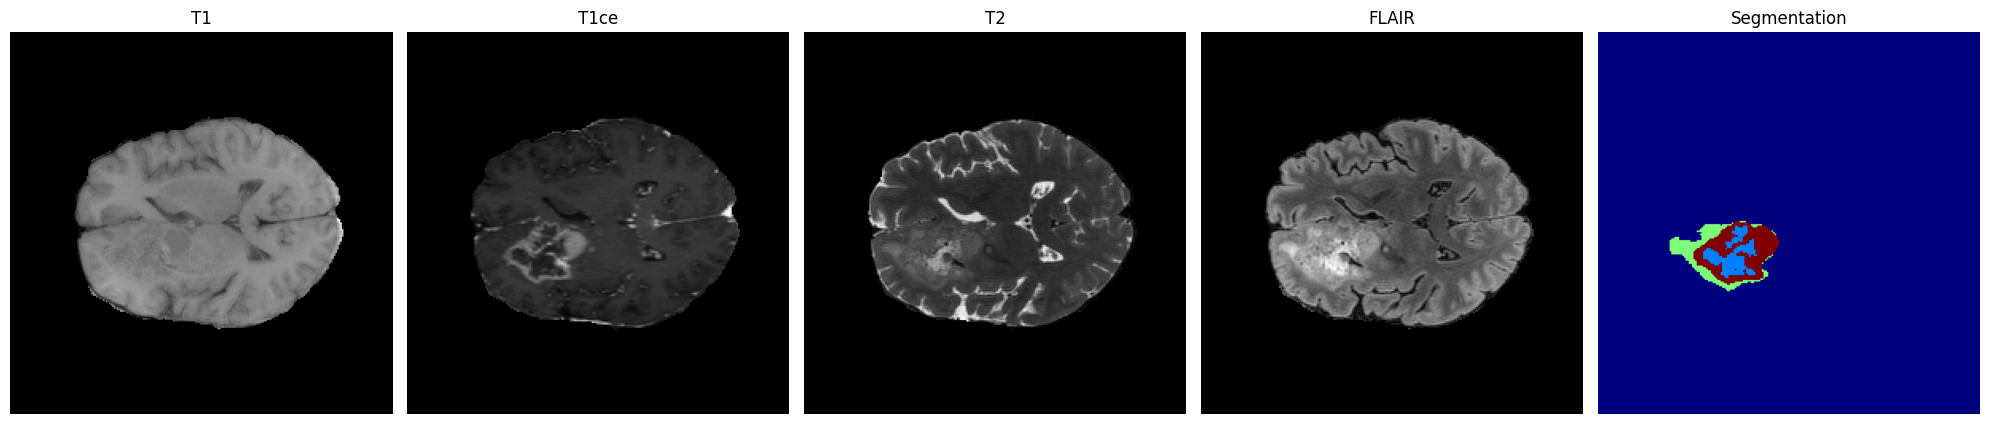

In [3]:
import os
import nibabel as nib
import matplotlib.pyplot as plt

# Dataset path
dataset_path = r"C:\BraTS2021"

# List of patients (ignoring .DS_Store)
patients = sorted([
    p for p in os.listdir(dataset_path)
    if p.startswith("BraTS2021_")
])

# Select the first patient
patient = patients[0]
patient_path = os.path.join(dataset_path, patient)

# Load the images
t1 = nib.load(os.path.join(patient_path, f"{patient}_t1.nii.gz")).get_fdata()
t1ce = nib.load(os.path.join(patient_path, f"{patient}_t1ce.nii.gz")).get_fdata()
t2 = nib.load(os.path.join(patient_path, f"{patient}_t2.nii.gz")).get_fdata()
flair = nib.load(os.path.join(patient_path, f"{patient}_flair.nii.gz")).get_fdata()
seg = nib.load(os.path.join(patient_path, f"{patient}_seg.nii.gz")).get_fdata()

# Select the middle slice
slice_idx = t1.shape[2] // 2

# Display the images
fig, axes = plt.subplots(1, 5, figsize=(20,5))

titles = ["T1", "T1ce", "T2", "FLAIR", "Segmentation"]
images = [t1, t1ce, t2, flair, seg]
cmaps = ["gray", "gray", "gray", "gray", "jet"]

for ax, img, title, cmap in zip(axes, images, titles, cmaps):
    ax.imshow(img[:, :, slice_idx], cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Building and Splitting the Data Lists (Train / Validation / Test)

In [7]:
data = []

for patient in patients:

    patient_path = os.path.join(dataset_path, patient)

    data.append({
        "image": [
            os.path.join(patient_path, f"{patient}_t1.nii.gz"),
            os.path.join(patient_path, f"{patient}_t1ce.nii.gz"),
            os.path.join(patient_path, f"{patient}_t2.nii.gz"),
            os.path.join(patient_path, f"{patient}_flair.nii.gz"),
        ],
        "label": os.path.join(patient_path, f"{patient}_seg.nii.gz"),
    })

print("Total Cases:", len(data))
print(data[0])

Total Cases: 1251
{'image': ['C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_t1.nii.gz', 'C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_t1ce.nii.gz', 'C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_t2.nii.gz', 'C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_flair.nii.gz'], 'label': 'C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_seg.nii.gz'}


In [8]:
train_files, test_files = train_test_split(
    data,
    test_size=0.15,
    random_state=42
)

train_files, val_files = train_test_split(
    train_files,
    test_size=0.1765,
    random_state=42
)

print("Training :", len(train_files))
print("Validation:", len(val_files))
print("Testing :", len(test_files))

Training : 875
Validation: 188
Testing : 188


## 4. Transforms and Converting Labels to WT / TC / ET

In [39]:
import torch
from monai.transforms import MapTransform

class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):

    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)

        for key in self.keys:

            label = d[key]

            if label.shape[0] == 1:
                label = label.squeeze(0)

            d[key] = torch.stack(
                [
                    ((label == 1) | (label == 2) | (label == 4)).float(),  # WT
                    ((label == 1) | (label == 4)).float(),                 # TC
                    (label == 4).float(),                                  # ET
                ],
                dim=0,
            )

        return d

In [40]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    NormalizeIntensityd,
    ResizeD,
    EnsureTyped,
)

train_transforms = Compose([

    LoadImaged(keys=["image", "label"]),

    EnsureChannelFirstd(keys=["image", "label"]),

    Orientationd(
        keys=["image", "label"],
        axcodes="RAS"
    ),

    NormalizeIntensityd(
        keys="image",
        nonzero=True,
        channel_wise=True
    ),

    ResizeD(
        keys=["image", "label"],
        spatial_size=(128, 128, 128),
        mode=("trilinear", "nearest")
    ),

    ConvertToMultiChannelBasedOnBratsClassesd(
        keys=["label"]
    ),

    EnsureTyped(
        keys=["image", "label"]
    )

])

In [58]:
from monai.data import Dataset

train_dataset = Dataset(
    data=train_files,
    transform=train_transforms
)

val_dataset = Dataset(
    data=val_files,
    transform=train_transforms
)

test_dataset = Dataset(
    data=test_files,
    transform=train_transforms
)

In [59]:
from monai.data import DataLoader

BATCH_SIZE = 1

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

## 5. Model Definition (3D U-Net) and Training Setup

In [52]:
import torch
from monai.networks.nets import UNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

print(model)
print("\nDevice:", device)

AttributeError: module 'torch._C' has no attribute '_get_all_dtypes'

In [33]:
from monai.losses import DiceLoss

criterion = DiceLoss(
    sigmoid=True,
    squared_pred=True,
    reduction="mean"
)

In [34]:
import torch

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

In [24]:
from torch import amp

scaler = amp.GradScaler("cuda")

## 6. Training

Final training loop: supports resuming training from the last checkpoint, and saves both the best model (`best_model.pth`) and a full checkpoint (`checkpoint.pth`) after every epoch.

In [63]:
import os
import time
import torch
from torch import amp

EPOCHS = 20

checkpoint_path = "checkpoint.pth"
best_model_path = "best_model.pth"

start_epoch = 0
best_val_loss = float("inf")

####################################################
# Load the latest checkpoint if it exists
####################################################
if os.path.exists(checkpoint_path):

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scaler.load_state_dict(checkpoint["scaler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]

    print("="*60)
    print(f"Resume training from Epoch {start_epoch+1}")
    print("="*60)

####################################################
# If no checkpoint exists but a best model does
####################################################
elif os.path.exists(best_model_path):

    model.load_state_dict(torch.load(best_model_path, map_location=device))

    print("="*60)
    print("Loaded best_model.pth")
    print("Training will continue from this model.")
    print("="*60)

####################################################
# If nothing exists
####################################################
else:

    print("="*60)
    print("No checkpoint found.")
    print("Training from scratch.")
    print("="*60)

####################################################
# Training
####################################################
for epoch in range(start_epoch, EPOCHS):

    start_time = time.time()

    ##############################
    # TRAIN
    ##############################
    model.train()

    running_train_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):

        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with amp.autocast("cuda"):

            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item()

        if (batch_idx + 1) % 20 == 0:

            print(
                f"Epoch [{epoch+1}/{EPOCHS}] "
                f"Batch [{batch_idx+1}/{len(train_loader)}] "
                f"Loss: {loss.item():.4f}"
            )

    avg_train_loss = running_train_loss / len(train_loader)

    ##############################
    # VALIDATION
    ##############################
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for batch in val_loader:

            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            with amp.autocast("cuda"):

                outputs = model(images)
                loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    ##############################
    # Save the best model
    ##############################
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(model.state_dict(), best_model_path)

        print("Best model saved.")

    ##############################
    # Save checkpoint
    ##############################
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_loss": best_val_loss,
    }, checkpoint_path)

    ##############################
    # Epoch summary
    ##############################
    print("\n===================================================")
    print(f"Epoch           : {epoch+1}/{EPOCHS}")
    print(f"Train Loss      : {avg_train_loss:.4f}")
    print(f"Validation Loss : {avg_val_loss:.4f}")
    print(f"Best Val Loss   : {best_val_loss:.4f}")
    print(f"Time            : {time.time()-start_time:.1f} seconds")
    print("Checkpoint saved.")
    print("===================================================\n")

print("Training Finished.")

C:\Users\eraze\AppData\Local\Temp\ipykernel_21816\3804207891.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locat

Loaded best_model.pth
Training will continue from this model.
Epoch [1/20] Batch [20/875] Loss: 0.0866
Epoch [1/20] Batch [40/875] Loss: 0.3505
Epoch [1/20] Batch [60/875] Loss: 0.1236
Epoch [1/20] Batch [80/875] Loss: 0.1556
Epoch [1/20] Batch [100/875] Loss: 0.4866
Epoch [1/20] Batch [120/875] Loss: 0.3789
Epoch [1/20] Batch [140/875] Loss: 0.1335
Epoch [1/20] Batch [160/875] Loss: 0.2519
Epoch [1/20] Batch [180/875] Loss: 0.1993
Epoch [1/20] Batch [200/875] Loss: 0.1169
Epoch [1/20] Batch [220/875] Loss: 0.2738
Epoch [1/20] Batch [240/875] Loss: 0.3465
Epoch [1/20] Batch [260/875] Loss: 0.3245
Epoch [1/20] Batch [280/875] Loss: 0.1481
Epoch [1/20] Batch [300/875] Loss: 0.1193
Epoch [1/20] Batch [320/875] Loss: 0.1081
Epoch [1/20] Batch [340/875] Loss: 0.2364
Epoch [1/20] Batch [360/875] Loss: 0.1300
Epoch [1/20] Batch [380/875] Loss: 0.0909
Epoch [1/20] Batch [400/875] Loss: 0.1064
Epoch [1/20] Batch [420/875] Loss: 0.1730
Epoch [1/20] Batch [440/875] Loss: 0.0515
Epoch [1/20] Batch

KeyboardInterrupt: 

## 7. Loading the Best Model for Evaluation

In [82]:
import torch
from monai.networks.nets import UNet

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

checkpoint = torch.load(
    "best_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint)
model.eval()

print("Device:", device)
print("Model loaded successfully.")

AttributeError: module 'torch._C' has no attribute '_get_all_dtypes'

## 8. Native-Space Evaluation

The model's prediction is upsampled from the network resolution (128³) back to the image's native space (240×240×155), then Dice and HD95 are computed.

**8.1** Overall per-patient evaluation (WT/TC/ET average) → used for Figures 3 and 4.

In [78]:
# ============================================================
# FINAL NATIVE-SPACE EVALUATION
# BraTS 2021 - Test set N=188
#
# 128^3 prediction
#        ↓
# Native space: 240 x 240 x 155
#        ↓
# threshold = 0.5
#        ↓
# Dice + HD95
#
# Empty-mask HD95 penalty = 373.13 mm
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from tqdm.auto import tqdm
from scipy.ndimage import binary_erosion, generate_binary_structure


# ============================================================
# 1. SETTINGS
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NATIVE_SHAPE = (240, 240, 155)

# BraTS native voxel spacing
NATIVE_SPACING = (1.0, 1.0, 1.0)

# IMPORTANT:
# This is the convention specified in the manuscript/reviewer note
EMPTY_MASK_PENALTY = 373.13

THRESHOLD = 0.5

print("Device:", DEVICE)
print("Native shape:", NATIVE_SHAPE)
print("Empty-mask HD95 penalty:", EMPTY_MASK_PENALTY, "mm")


# ============================================================
# 2. DICE
# ============================================================

def dice_score(pred, target):
    """
    Binary Dice coefficient.
    """

    pred = np.asarray(pred).astype(bool)
    target = np.asarray(target).astype(bool)

    pred_sum = pred.sum()
    target_sum = target.sum()

    # Both masks empty
    if pred_sum == 0 and target_sum == 0:
        return 1.0

    # One empty, the other non-empty
    if pred_sum == 0 or target_sum == 0:
        return 0.0

    intersection = np.logical_and(pred, target).sum()

    return (2.0 * intersection) / (pred_sum + target_sum)


# ============================================================
# 3. HD95
# ============================================================

def hd95_binary(pred, target, penalty=EMPTY_MASK_PENALTY):
    """
    95th percentile Hausdorff distance.

    Convention:
    - both masks empty -> 0 mm
    - one mask empty    -> 373.13 mm
    - otherwise compute symmetric HD95
    """

    pred = np.asarray(pred).astype(bool)
    target = np.asarray(target).astype(bool)

    pred_empty = not np.any(pred)
    target_empty = not np.any(target)

    # --------------------------------------------------------
    # Both masks empty
    # --------------------------------------------------------
    if pred_empty and target_empty:
        return 0.0

    # --------------------------------------------------------
    # One mask empty
    # --------------------------------------------------------
    if pred_empty or target_empty:
        return float(penalty)

    # --------------------------------------------------------
    # Surface extraction
    # --------------------------------------------------------

    structure = generate_binary_structure(3, 1)

    pred_eroded = binary_erosion(
        pred,
        structure=structure,
        border_value=0
    )

    target_eroded = binary_erosion(
        target,
        structure=structure,
        border_value=0
    )

    pred_surface = pred ^ pred_eroded
    target_surface = target ^ target_eroded

    pred_points = np.argwhere(pred_surface)
    target_points = np.argwhere(target_surface)

    # Safety fallback
    if len(pred_points) == 0 or len(target_points) == 0:
        return float(penalty)

    # --------------------------------------------------------
    # Distances
    # --------------------------------------------------------

    # Native space is isotropic 1 mm
    pred_points = pred_points.astype(np.float64)
    target_points = target_points.astype(np.float64)

    # Compute pairwise Euclidean distances
    diff = pred_points[:, None, :] - target_points[None, :, :]
    distances = np.sqrt(np.sum(diff ** 2, axis=2))

    # Directed distances
    pred_to_target = np.min(distances, axis=1)
    target_to_pred = np.min(distances, axis=0)

    # Symmetric HD95
    all_distances = np.concatenate([
        pred_to_target,
        target_to_pred
    ])

    return float(np.percentile(all_distances, 95))


# ============================================================
# 4. REGION DEFINITIONS
# ============================================================

# BraTS label convention:
# 1 = necrotic/non-enhancing tumor
# 2 = edema
# 4 = enhancing tumor
#
# WT = labels 1,2,4
# TC = labels 1,4
# ET = label 4
#
# However, your model output has 3 channels:
# WT, TC, ET
#
# Therefore we evaluate the three prediction channels
# directly against the corresponding three target channels.


# ============================================================
# 5. NATIVE-SPACE RESAMPLING
# ============================================================

def resize_probability_map(prob_map, native_shape):
    """
    Upsample probability map from 128^3 to native space
    using trilinear interpolation.

    Input:
        prob_map: torch.Tensor [1, 1, D, H, W]

    Output:
        numpy array [D, H, W]
    """

    if not torch.is_tensor(prob_map):
        prob_map = torch.tensor(
            prob_map,
            dtype=torch.float32
        )

    if prob_map.ndim == 3:
        prob_map = prob_map.unsqueeze(0).unsqueeze(0)

    elif prob_map.ndim == 4:
        prob_map = prob_map.unsqueeze(0)

    prob_map = prob_map.float()

    native = F.interpolate(
        prob_map,
        size=native_shape,
        mode="trilinear",
        align_corners=False
    )

    return native.squeeze().cpu().numpy()


# ============================================================
# 6. LABEL RESAMPLING
# ============================================================

def resize_label_mask(mask, native_shape):
    """
    Resize binary target mask to native space.

    Nearest-neighbor interpolation is used for segmentation labels.
    """

    if not torch.is_tensor(mask):
        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

    if mask.ndim == 3:
        mask = mask.unsqueeze(0).unsqueeze(0)

    elif mask.ndim == 4:
        mask = mask.unsqueeze(0)

    mask = mask.float()

    native = F.interpolate(
        mask,
        size=native_shape,
        mode="nearest"
    )

    return native.squeeze().cpu().numpy() > 0.5


# ============================================================
# 7. EVALUATION
# ============================================================

results = []

model.eval()

with torch.no_grad():

    for patient_idx, batch in enumerate(
        tqdm(test_loader, desc="Native-space evaluation"),
        start=1
    ):

        # ----------------------------------------------------
        # Input
        # ----------------------------------------------------

        images = batch["image"].to(DEVICE)

        labels = batch["label"]

        # ----------------------------------------------------
        # Prediction at 128^3
        # ----------------------------------------------------

        outputs = model(images)

        # ----------------------------------------------------
        # Convert logits/probabilities
        #
        # Your model uses sigmoid-style multiclass output.
        # ----------------------------------------------------

        probabilities = torch.sigmoid(outputs)

        # ----------------------------------------------------
        # Process each patient in batch
        # ----------------------------------------------------

        batch_size = probabilities.shape[0]

        for b in range(batch_size):

            patient_number = patient_idx

            patient_result = {
                "Patient": patient_number
            }

            patient_dices = []
            patient_hd95s = []

            # =================================================
            # WT / TC / ET
            # =================================================

            for region_idx, region_name in enumerate(
                ["WT", "TC", "ET"]
            ):

                # ---------------------------------------------
                # Prediction probability at 128^3
                # ---------------------------------------------

                pred_prob = probabilities[
                    b,
                    region_idx
                ]

                # ---------------------------------------------
                # Upsample probability to native space
                # ---------------------------------------------

                pred_prob_native = resize_probability_map(
                    pred_prob,
                    NATIVE_SHAPE
                )

                # ---------------------------------------------
                # IMPORTANT:
                # Threshold AFTER interpolation
                # ---------------------------------------------

                pred_native = (
                    pred_prob_native >= THRESHOLD
                )

                # ---------------------------------------------
                # Ground truth
                # ---------------------------------------------

                target = labels[b, region_idx]

                target_native = resize_label_mask(
                    target,
                    NATIVE_SHAPE
                )

                # ---------------------------------------------
                # Dice
                # ---------------------------------------------

                dice = dice_score(
                    pred_native,
                    target_native
                )

                # ---------------------------------------------
                # HD95
                # ---------------------------------------------

                hd95 = hd95_binary(
                    pred_native,
                    target_native,
                    penalty=EMPTY_MASK_PENALTY
                )

                # ---------------------------------------------
                # Save
                # ---------------------------------------------

                patient_result[
                    f"{region_name}_Dice"
                ] = dice

                patient_result[
                    f"{region_name}_HD95_mm"
                ] = hd95

                patient_dices.append(dice)
                patient_hd95s.append(hd95)

            # =================================================
            # Patient-level aggregation
            # =================================================

            patient_result["Patient_Dice"] = float(
                np.mean(patient_dices)
            )

            patient_result["Patient_HD95_mm"] = float(
                np.mean(patient_hd95s)
            )

            results.append(patient_result)


# ============================================================
# 8. DATAFRAME
# ============================================================

df_native = pd.DataFrame(results)

print("\n======================================")
print("NATIVE-SPACE RESULTS")
print("======================================")

print(df_native.head())


# ============================================================
# 9. FINAL DICE STATISTICS
# ============================================================

mean_dice = df_native["Patient_Dice"].mean()
median_dice = df_native["Patient_Dice"].median()
std_dice = df_native["Patient_Dice"].std()


# ============================================================
# 10. FINAL HD95 STATISTICS
# ============================================================

mean_hd95 = df_native["Patient_HD95_mm"].mean()
median_hd95 = df_native["Patient_HD95_mm"].median()

q1_hd95 = df_native["Patient_HD95_mm"].quantile(0.25)
q3_hd95 = df_native["Patient_HD95_mm"].quantile(0.75)

iqr_hd95 = q3_hd95 - q1_hd95


# ============================================================
# 11. J2 — EMPTY-MASK PENALTY COUNTS
# ============================================================

print("\n======================================")
print("J2 — EMPTY-MASK PENALTY COUNTS")
print("======================================")

for region in ["WT", "TC", "ET"]:

    column = f"{region}_HD95_mm"

    count_penalty = np.isclose(
        df_native[column].values,
        EMPTY_MASK_PENALTY,
        atol=1e-6
    ).sum()

    print(
        f"{region}: "
        f"{count_penalty} / {len(df_native)} "
        f"patients received {EMPTY_MASK_PENALTY:.2f} mm penalty"
    )


# ============================================================
# 12. FINAL STATISTICS
# ============================================================

print("\n======================================")
print("FINAL NATIVE-SPACE STATISTICS")
print("======================================")

print(f"Mean Dice       : {mean_dice:.4f}")
print(f"Median Dice     : {median_dice:.4f}")
print(f"Std Dice        : {std_dice:.4f}")

print()

print(f"Mean HD95       : {mean_hd95:.4f} mm")
print(f"Median HD95     : {median_hd95:.4f} mm")
print(f"Q1 HD95         : {q1_hd95:.4f} mm")
print(f"Q3 HD95         : {q3_hd95:.4f} mm")
print(f"IQR HD95        : {iqr_hd95:.4f} mm")


# ============================================================
# 13. REGION-WISE STATISTICS
# ============================================================

print("\n======================================")
print("REGION-WISE NATIVE-SPACE RESULTS")
print("======================================")

for region in ["WT", "TC", "ET"]:

    dice_col = f"{region}_Dice"
    hd_col = f"{region}_HD95_mm"

    print(f"\n{region}")

    print(
        f"Dice mean   : "
        f"{df_native[dice_col].mean():.4f}"
    )

    print(
        f"Dice median : "
        f"{df_native[dice_col].median():.4f}"
    )

    print(
        f"Dice SD     : "
        f"{df_native[dice_col].std():.4f}"
    )

    print(
        f"HD95 mean   : "
        f"{df_native[hd_col].mean():.4f} mm"
    )

    print(
        f"HD95 median : "
        f"{df_native[hd_col].median():.4f} mm"
    )

    print(
        f"HD95 Q1     : "
        f"{df_native[hd_col].quantile(0.25):.4f} mm"
    )

    print(
        f"HD95 Q3     : "
        f"{df_native[hd_col].quantile(0.75):.4f} mm"
    )

    penalty_count = np.isclose(
        df_native[hd_col].values,
        EMPTY_MASK_PENALTY,
        atol=1e-6
    ).sum()

    print(
        f"Penalty     : "
        f"{penalty_count} patients"
    )


# ============================================================
# 14. CHECK PATIENT-LEVEL RESULTS
# ============================================================

print("\n======================================")
print("FIRST 5 PATIENTS")
print("======================================")

print(
    df_native[
        [
            "Patient",
            "WT_Dice",
            "TC_Dice",
            "ET_Dice",
            "Patient_Dice",
            "WT_HD95_mm",
            "TC_HD95_mm",
            "ET_HD95_mm",
            "Patient_HD95_mm"
        ]
    ].head()
)


# ============================================================
# 15. SAVE COMPLETE RESULTS
# ============================================================

output_file = "Native_Space_Final_Results_188_patients.csv"

df_native.to_csv(
    output_file,
    index=False
)

print("\n======================================")
print("SAVED")
print("======================================")

print(output_file)

Device: cuda
Native shape: (240, 240, 155)
Empty-mask HD95 penalty: 373.13 mm


Native-space evaluation:   0%|          | 0/188 [00:00<?, ?it/s]

MemoryError: Unable to allocate 6.76 GiB for an array with shape (26376, 34424) and data type float64

**8.2** Detailed per-region evaluation (WT/TC/ET) with volumes → used for Figure 5.

In [69]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import nibabel as nib

from scipy.ndimage import binary_erosion, distance_transform_edt


# ============================================================
# SETTINGS
# ============================================================

NATIVE_SIZE = (240, 240, 155)
NATIVE_SPACING = (1.0, 1.0, 1.0)
THRESHOLD = 0.5


# ============================================================
# DICE
# ============================================================

def dice_score(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    pred_sum = pred.sum()
    gt_sum = gt.sum()

    if pred_sum == 0 and gt_sum == 0:
        return 1.0

    if pred_sum == 0 or gt_sum == 0:
        return 0.0

    intersection = np.logical_and(pred, gt).sum()

    return (
        2.0 * intersection
        / (pred_sum + gt_sum)
    )


# ============================================================
# HD95
# ============================================================

def hd95(pred, gt, spacing=(1.0, 1.0, 1.0)):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    # Both empty
    if not pred.any() and not gt.any():
        return 0.0

    # One empty
    if not pred.any() or not gt.any():
        return np.nan

    pred_surface = pred ^ binary_erosion(pred)
    gt_surface = gt ^ binary_erosion(gt)

    dt_gt = distance_transform_edt(
        ~gt_surface,
        sampling=spacing
    )

    dt_pred = distance_transform_edt(
        ~pred_surface,
        sampling=spacing
    )

    distances_pred_to_gt = dt_gt[pred_surface]
    distances_gt_to_pred = dt_pred[gt_surface]

    distances = np.concatenate([
        distances_pred_to_gt,
        distances_gt_to_pred
    ])

    return np.percentile(distances, 95)


# ============================================================
# LOAD NATIVE LABEL IN RAS
# ============================================================

def load_native_label_ras(label_path):

    nii = nib.load(label_path)

    # Convert original orientation -> RAS
    nii_ras = nib.as_closest_canonical(nii)

    label = nii_ras.get_fdata()

    label = np.squeeze(label)

    # Check native dimensions
    if label.shape != NATIVE_SIZE:

        raise ValueError(
            f"Unexpected native shape: {label.shape}, "
            f"expected {NATIVE_SIZE}"
        )

    # Check native spacing
    spacing = nii_ras.header.get_zooms()[:3]

    print("Native RAS shape:", label.shape)
    print("Native RAS spacing:", spacing)

    return label


# ============================================================
# BRATS REGIONS
# ============================================================

def get_brats_regions(label):

    WT = (
        (label == 1) |
        (label == 2) |
        (label == 4)
    )

    TC = (
        (label == 1) |
        (label == 4)
    )

    ET = (
        label == 4
    )

    return WT, TC, ET


# ============================================================
# EVALUATION
# ============================================================

model.eval()

results = []


with torch.no_grad():

    for patient_id, batch in enumerate(test_loader):

        print("\n======================================")
        print(f"Patient {patient_id + 1:03d}")
        print("======================================")

        # ----------------------------------------------------
        # IMAGE
        # ----------------------------------------------------

        image = batch["image"].to(device)

        # ----------------------------------------------------
        # MODEL
        # ----------------------------------------------------

        output = model(image)

        probabilities = torch.sigmoid(output)

        print(
            "Probability shape:",
            tuple(probabilities.shape)
        )

        # ----------------------------------------------------
        # RESIZE PROBABILITIES
        #
        # 128³ -> 240×240×155
        #
        # IMPORTANT:
        # interpolation is applied BEFORE threshold
        # ----------------------------------------------------

        probabilities_native = F.interpolate(
            probabilities,
            size=NATIVE_SIZE,
            mode="trilinear",
            align_corners=False
        )

        # ----------------------------------------------------
        # THRESHOLD IN NATIVE SPACE
        # ----------------------------------------------------

        prediction_native = (
            probabilities_native > THRESHOLD
        )

        prediction_native = (
            prediction_native
            .cpu()
            .numpy()[0]
        )

        # ----------------------------------------------------
        # ORIGINAL LABEL PATH
        # ----------------------------------------------------

        label_path = (
            batch["label"]
            .meta["filename_or_obj"]
        )

        if isinstance(label_path, (list, tuple)):
            label_path = label_path[0]

        print("Label:", label_path)

        # ----------------------------------------------------
        # LOAD NATIVE LABEL AND CONVERT TO RAS
        # ----------------------------------------------------

        native_label = load_native_label_ras(
            label_path
        )

        # ----------------------------------------------------
        # CREATE WT / TC / ET
        # ----------------------------------------------------

        gt_WT, gt_TC, gt_ET = get_brats_regions(
            native_label
        )

        # ----------------------------------------------------
        # PREDICTION CHANNELS
        # ----------------------------------------------------

        pred_WT = prediction_native[0]
        pred_TC = prediction_native[1]
        pred_ET = prediction_native[2]

        # ----------------------------------------------------
        # DICE
        # ----------------------------------------------------

        dice_WT = dice_score(
            pred_WT,
            gt_WT
        )

        dice_TC = dice_score(
            pred_TC,
            gt_TC
        )

        dice_ET = dice_score(
            pred_ET,
            gt_ET
        )

        # ----------------------------------------------------
        # HD95
        # ----------------------------------------------------

        hd_WT = hd95(
            pred_WT,
            gt_WT,
            NATIVE_SPACING
        )

        hd_TC = hd95(
            pred_TC,
            gt_TC,
            NATIVE_SPACING
        )

        hd_ET = hd95(
            pred_ET,
            gt_ET,
            NATIVE_SPACING
        )

        # ----------------------------------------------------
        # VOLUMES
        #
        # 1 voxel = 1 mm³
        # ----------------------------------------------------

        pred_WT_volume_cm3 = (
            pred_WT.sum() / 1000.0
        )

        pred_TC_volume_cm3 = (
            pred_TC.sum() / 1000.0
        )

        pred_ET_volume_cm3 = (
            pred_ET.sum() / 1000.0
        )

        gt_WT_volume_cm3 = (
            gt_WT.sum() / 1000.0
        )

        gt_TC_volume_cm3 = (
            gt_TC.sum() / 1000.0
        )

        gt_ET_volume_cm3 = (
            gt_ET.sum() / 1000.0
        )

        # ----------------------------------------------------
        # SAVE
        # ----------------------------------------------------

        results.append([
            patient_id + 1,

            dice_WT,
            dice_TC,
            dice_ET,

            hd_WT,
            hd_TC,
            hd_ET,

            pred_WT_volume_cm3,
            pred_TC_volume_cm3,
            pred_ET_volume_cm3,

            gt_WT_volume_cm3,
            gt_TC_volume_cm3,
            gt_ET_volume_cm3
        ])

        # ----------------------------------------------------
        # PRINT
        # ----------------------------------------------------

        print(
            f"WT | DSC={dice_WT:.4f} | "
            f"HD95={hd_WT:.2f} mm | "
            f"PredVol={pred_WT_volume_cm3:.2f} cm³"
        )

        print(
            f"TC | DSC={dice_TC:.4f} | "
            f"HD95={hd_TC:.2f} mm | "
            f"PredVol={pred_TC_volume_cm3:.2f} cm³"
        )

        print(
            f"ET | DSC={dice_ET:.4f} | "
            f"HD95={hd_ET:.2f} mm | "
            f"PredVol={pred_ET_volume_cm3:.2f} cm³"
        )


# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(
    results,
    columns=[
        "Patient",

        "DSC_WT",
        "DSC_TC",
        "DSC_ET",

        "HD95_WT_mm",
        "HD95_TC_mm",
        "HD95_ET_mm",

        "Pred_Volume_WT_cm3",
        "Pred_Volume_TC_cm3",
        "Pred_Volume_ET_cm3",

        "GT_Volume_WT_cm3",
        "GT_Volume_TC_cm3",
        "GT_Volume_ET_cm3"
    ]
)


# ============================================================
# SAVE
# ============================================================

df.to_csv(
    "Native_Space_Metrics_WT_TC_ET.csv",
    index=False
)


# ============================================================
# FINAL STATISTICS
# ============================================================

print("\n======================================")
print("NATIVE-SPACE FINAL RESULTS")
print("======================================")


print("\nMean DSC")
print(f"WT : {df['DSC_WT'].mean():.4f}")
print(f"TC : {df['DSC_TC'].mean():.4f}")
print(f"ET : {df['DSC_ET'].mean():.4f}")


print("\nSD DSC")
print(f"WT : {df['DSC_WT'].std():.4f}")
print(f"TC : {df['DSC_TC'].std():.4f}")
print(f"ET : {df['DSC_ET'].std():.4f}")


print("\nMean HD95")
print(f"WT : {df['HD95_WT_mm'].mean():.4f} mm")
print(f"TC : {df['HD95_TC_mm'].mean():.4f} mm")
print(f"ET : {df['HD95_ET_mm'].mean():.4f} mm")


print("\nSD HD95")
print(f"WT : {df['HD95_WT_mm'].std():.4f} mm")
print(f"TC : {df['HD95_TC_mm'].std():.4f} mm")
print(f"ET : {df['HD95_ET_mm'].std():.4f} mm")


print("\nMean Predicted Volumes")
print(
    f"WT : {df['Pred_Volume_WT_cm3'].mean():.4f} cm³"
)
print(
    f"TC : {df['Pred_Volume_TC_cm3'].mean():.4f} cm³"
)
print(
    f"ET : {df['Pred_Volume_ET_cm3'].mean():.4f} cm³"
)


print("\n======================================")
print("Saved:")
print("Native_Space_Metrics_WT_TC_ET.csv")
print("======================================")


Patient 001
Probability shape: (1, 3, 128, 128, 128)
Label: C:\BraTS2021\BraTS2021_01137\BraTS2021_01137_seg.nii.gz
Native RAS shape: (240, 240, 155)
Native RAS spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
WT | DSC=0.9267 | HD95=2.00 mm | PredVol=39.18 cm³
TC | DSC=0.8519 | HD95=3.00 mm | PredVol=12.70 cm³
ET | DSC=0.6870 | HD95=5.83 mm | PredVol=8.06 cm³

Patient 002
Probability shape: (1, 3, 128, 128, 128)
Label: C:\BraTS2021\BraTS2021_01659\BraTS2021_01659_seg.nii.gz
Native RAS shape: (240, 240, 155)
Native RAS spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
WT | DSC=0.9247 | HD95=2.24 mm | PredVol=143.81 cm³
TC | DSC=0.9252 | HD95=2.24 mm | PredVol=71.34 cm³
ET | DSC=0.9046 | HD95=2.00 mm | PredVol=61.91 cm³

Patient 003
Probability shape: (1, 3, 128, 128, 128)
Label: C:\BraTS2021\BraTS2021_01483\BraTS2021_01483_seg.nii.gz
Native RAS shape: (240, 240, 155)
Native RAS spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
WT | DSC=0.8759 | HD95=5.

## 9. Model Complexity (FLOPs / MACs)

In [53]:
%pip install -U fvcore

Note: you may need to restart the kernel to use updated packages.Collecting fvcore
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61446 sha256=a9103286aa241dd91eda31c4e55755ee967230e697586ea6124821fcb75243ee
  Stored in directory: c:\users\eraze\appdata\local\pip\cache\wheels\01\c0\af\77c1cf53a1be9e42

In [55]:
%pip install -U ptflops

In [54]:
# ============================================================
# I1 — VERIFY MODEL FLOPs / MACs
# ============================================================

import torch
from fvcore.nn import FlopCountAnalysis, flop_count_table

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

dummy_input = torch.randn(
    1, 4, 128, 128, 128,
    device=device
)

# ------------------------------------------------------------
# FLOP analysis
# ------------------------------------------------------------

flops = FlopCountAnalysis(
    model,
    dummy_input
)

flops.unsupported_ops_warnings(False)

total_flops = flops.total()

print("=" * 70)
print("I1 — FLOPs VERIFICATION")
print("=" * 70)

print(f"Total FLOPs (fvcore): {total_flops:,.0f}")
print(f"Total GFLOPs        : {total_flops / 1e9:.4f}")

print("\n" + "=" * 70)
print("BY OPERATOR")
print("=" * 70)

print(flops.by_operator())

print("\n" + "=" * 70)
print("UNSUPPORTED OPERATORS")
print("=" * 70)

print(flops.unsupported_ops())

print("\n" + "=" * 70)
print("MODULE-LEVEL FLOP TABLE")
print("=" * 70)

print(
    flop_count_table(
        flops,
        max_depth=4
    )
)

print("\n" + "=" * 70)
print("I1 COMPLETE")
print("=" * 70)

I1 — FLOPs VERIFICATION
Total FLOPs (fvcore): 48,797,581,312
Total GFLOPs        : 48.7976

BY OPERATOR
Counter({'conv': 48593108992, 'instance_norm': 204472320})

UNSUPPORTED OPERATORS
Counter({'aten::prelu': 17, 'aten::add': 9})

MODULE-LEVEL FLOP TABLE
| module                                          | #parameters or shape   | #flops   |
|:------------------------------------------------|:-----------------------|:---------|
| model                                           | 19.224M                | 48.798G  |
| 0                                               | 34.658K                | 9.127G   |
| 0.conv                                          | 31.17K                 | 8.221G   |
| 0.conv.unit0                                    | 3.489K                 | 0.94G    |
| 0.conv.unit0.conv                               | 3.488K                 | 0.906G   |
| 0.conv.unit0.adn                                | 1                      | 33.554M  |
| 0.conv.unit1                          

In [56]:
import torch
from ptflops import get_model_complexity_info

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

macs, params = get_model_complexity_info(
    model,
    (4, 128, 128, 128),
    as_strings=False,
    print_per_layer_stat=False,
    verbose=False
)

print("=" * 70)
print("I1 — PTFlops CROSS-CHECK")
print("=" * 70)

print(f"MACs       : {macs:,.0f}")
print(f"GMACs      : {macs / 1e9:.4f}")

print(f"Parameters : {params:,.0f}")
print(f"Millions   : {params / 1e6:.4f}")

print(f"\nFLOPs (2 × MACs) : {2 * macs / 1e9:.4f} GFLOPs")

print("=" * 70)
print("I1 PTFlops COMPLETE")
print("=" * 70)

I1 — PTFlops CROSS-CHECK
MACs       : 48,815,276,032
GMACs      : 48.8153
Parameters : 19,223,978
Millions   : 19.2240

FLOPs (2 × MACs) : 97.6306 GFLOPs
I1 PTFlops COMPLETE


## 10. Quantitative Publication Figures

### Figure 3 — Per-Patient Dice

FIGURE 3 — FINAL DICE STATISTICS
Number of patients : 188
Mean Dice          : 0.8147
Median Dice        : 0.8566
Std Dice           : 0.1273


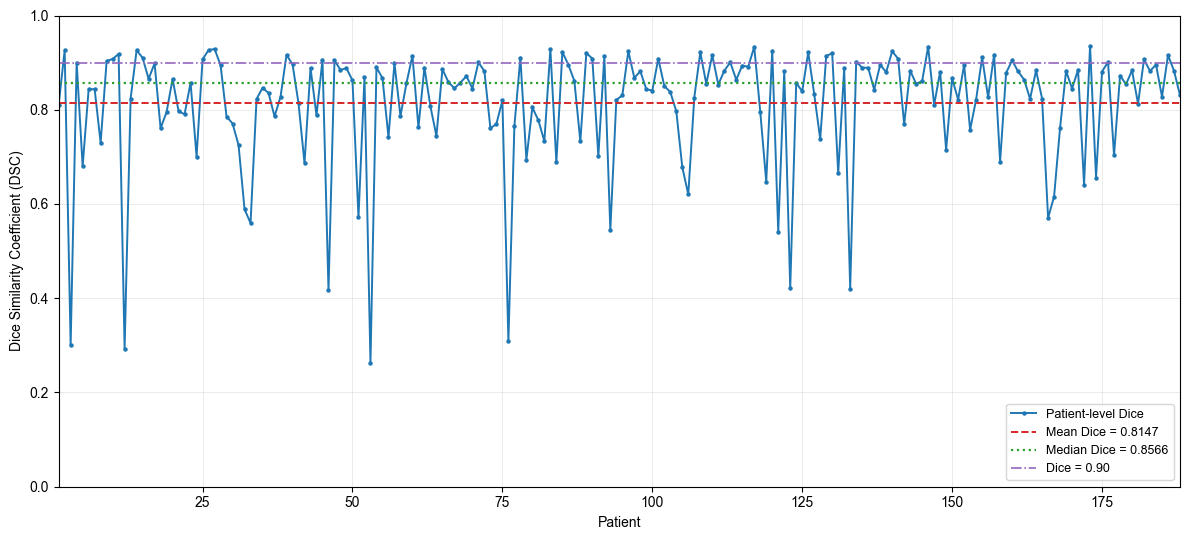


FIGURE 3 SAVED SUCCESSFULLY
PNG : C:\Users\eraze\saved\Fig3_Per_Patient_Dice_Native_Space.png
PDF : C:\Users\eraze\saved\Fig3_Per_Patient_Dice_Native_Space.pdf
PNG resolution : 600 dpi
Internal title : Removed
Font           : Arial
Font size      : 10 pt
Output folder  : saved


In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# FIGURE 3 — Per-patient Dice Coefficient
# FINAL NATIVE-SPACE TEST RESULTS
# N = 188
# Publication-ready version
# ============================================================

# ------------------------------------------------------------
# 1. Create output folder
# ------------------------------------------------------------

output_dir = "saved"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 2. Load FINAL patient-level test results
# ------------------------------------------------------------

csv_file = "Native_Space_HD95_DSC_188_patients.csv"

df = pd.read_csv(csv_file)

# ------------------------------------------------------------
# 3. Check required columns
# ------------------------------------------------------------

required_columns = ["Patient", "Patient_Dice"]

missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ------------------------------------------------------------
# 4. Extract patient-level Dice
# ------------------------------------------------------------

patients = pd.to_numeric(
    df["Patient"],
    errors="coerce"
)

dice = pd.to_numeric(
    df["Patient_Dice"],
    errors="coerce"
)

valid = patients.notna() & dice.notna()

patients = patients[valid].astype(int)
dice = dice[valid].astype(float)

# Sort by patient number
order = np.argsort(patients)

patients = patients.iloc[order].to_numpy()
dice = dice.iloc[order].to_numpy()

# ------------------------------------------------------------
# 5. Calculate statistics
# ------------------------------------------------------------

mean_dice = np.mean(dice)
median_dice = np.median(dice)
std_dice = np.std(dice, ddof=1)

print("=" * 70)
print("FIGURE 3 — FINAL DICE STATISTICS")
print("=" * 70)

print(f"Number of patients : {len(dice)}")
print(f"Mean Dice          : {mean_dice:.4f}")
print(f"Median Dice        : {median_dice:.4f}")
print(f"Std Dice           : {std_dice:.4f}")

# ------------------------------------------------------------
# 6. Publication font
# ------------------------------------------------------------

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 10

# ------------------------------------------------------------
# 7. Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 5.5)
)

# ------------------------------------------------------------
# 8. Patient-level Dice
# ------------------------------------------------------------

ax.plot(
    patients,
    dice,
    linewidth=1.4,
    marker="o",
    markersize=2.2,
    label="Patient-level Dice",
    color="#1f77b4"
)

# ------------------------------------------------------------
# 9. Mean Dice
# ------------------------------------------------------------

ax.axhline(
    mean_dice,
    linestyle="--",
    linewidth=1.4,
    label=f"Mean Dice = {mean_dice:.4f}",
    color="#d62728"
)

# ------------------------------------------------------------
# 10. Median Dice
# ------------------------------------------------------------

ax.axhline(
    median_dice,
    linestyle=":",
    linewidth=1.6,
    label=f"Median Dice = {median_dice:.4f}",
    color="#2ca02c"
)

# ------------------------------------------------------------
# 11. Dice = 0.90 reference
# ------------------------------------------------------------

ax.axhline(
    0.90,
    linestyle="-.",
    linewidth=1.2,
    label="Dice = 0.90",
    color="#9467bd"
)

# ------------------------------------------------------------
# 12. Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Patient",
    fontsize=10
)

ax.set_ylabel(
    "Dice Similarity Coefficient (DSC)",
    fontsize=10
)

# ------------------------------------------------------------
# IMPORTANT:
# No internal title — required by guideline 6.3
# ------------------------------------------------------------

# No ax.set_title()

# ------------------------------------------------------------
# 13. Axis limits
# ------------------------------------------------------------

ax.set_xlim(
    patients.min(),
    patients.max()
)

ax.set_ylim(
    0,
    1.0
)

# ------------------------------------------------------------
# 14. Grid
# ------------------------------------------------------------

ax.grid(
    True,
    alpha=0.25,
    linewidth=0.7
)

# ------------------------------------------------------------
# 15. Legend
# ------------------------------------------------------------

ax.legend(
    loc="lower right",
    frameon=True,
    fontsize=9
)

# ------------------------------------------------------------
# 16. Layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# 17. Save files
# ------------------------------------------------------------

png_file = os.path.join(
    output_dir,
    "Fig3_Per_Patient_Dice_Native_Space.png"
)

pdf_file = os.path.join(
    output_dir,
    "Fig3_Per_Patient_Dice_Native_Space.pdf"
)

# PNG — 600 dpi
plt.savefig(
    png_file,
    dpi=600,
    bbox_inches="tight"
)

# PDF — vector format
plt.savefig(
    pdf_file,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 18. Confirmation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIGURE 3 SAVED SUCCESSFULLY")
print("=" * 70)

print(f"PNG : {os.path.abspath(png_file)}")
print(f"PDF : {os.path.abspath(pdf_file)}")
print("PNG resolution : 600 dpi")
print("Internal title : Removed")
print("Font           : Arial")
print("Font size      : 10 pt")
print("Output folder  : saved")
print("=" * 70)

### Figure 4 — Per-Patient HD95

FIGURE 4 — FINAL HD95 STATISTICS
Patients : 188
Mean     : 8.8493 mm
Median   : 3.4388 mm
Q1       : 2.3268 mm
Q3       : 7.5500 mm
IQR      : 5.2232 mm
Penalty  : 373.13 mm


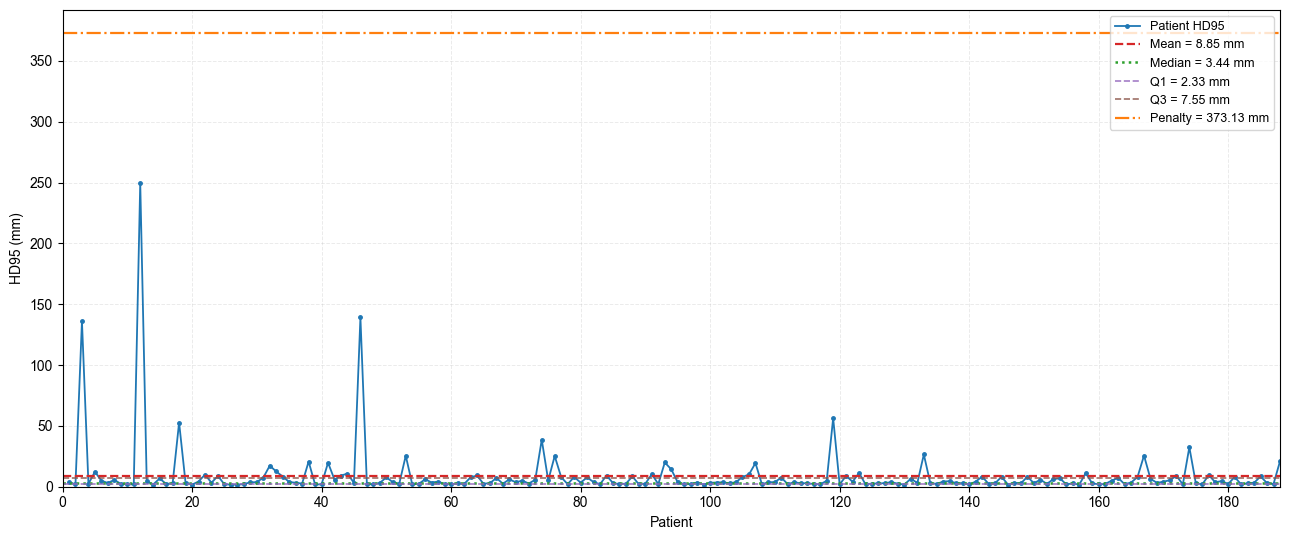


FIGURE 4 SAVED SUCCESSFULLY
PNG : C:\Users\eraze\saved\Fig4_Per_Patient_HD95_Native_Space.png
PDF : C:\Users\eraze\saved\Fig4_Per_Patient_HD95_Native_Space.pdf
PNG resolution : 600 dpi
Internal title : REMOVED
Font           : Arial
Font size      : 10 pt
Output folder  : saved


In [93]:
# ============================================================
# FIGURE 4 — Per-patient HD95 (N=188)
# NATIVE SPACE
# FINAL PUBLICATION VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# 1. Create output folder
# ------------------------------------------------------------

output_dir = "saved"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 2. Load native-space results
# ------------------------------------------------------------

csv_file = "Native_Space_HD95_DSC_188_patients.csv"

df = pd.read_csv(csv_file)

# ------------------------------------------------------------
# 3. Check required columns
# ------------------------------------------------------------

required_columns = [
    "Patient",
    "Patient_HD95_mm"
]

missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ------------------------------------------------------------
# 4. Extract patient-level HD95
# ------------------------------------------------------------

patients = pd.to_numeric(
    df["Patient"],
    errors="coerce"
)

hd95 = pd.to_numeric(
    df["Patient_HD95_mm"],
    errors="coerce"
)

# Remove invalid rows
valid = patients.notna() & hd95.notna()

patients = patients[valid].astype(int)
hd95 = hd95[valid].astype(float)

# Sort by patient number
order = np.argsort(patients)

patients = patients.iloc[order].to_numpy()
hd95 = hd95.iloc[order].to_numpy()

# ------------------------------------------------------------
# 5. Statistics
# ------------------------------------------------------------

mean_hd95 = np.mean(hd95)
median_hd95 = np.median(hd95)

q1 = np.quantile(hd95, 0.25)
q3 = np.quantile(hd95, 0.75)
iqr = q3 - q1

penalty = 373.13

print("=" * 70)
print("FIGURE 4 — FINAL HD95 STATISTICS")
print("=" * 70)

print(f"Patients : {len(hd95)}")
print(f"Mean     : {mean_hd95:.4f} mm")
print(f"Median   : {median_hd95:.4f} mm")
print(f"Q1       : {q1:.4f} mm")
print(f"Q3       : {q3:.4f} mm")
print(f"IQR      : {iqr:.4f} mm")
print(f"Penalty  : {penalty:.2f} mm")

# ------------------------------------------------------------
# 6. Publication font
# ------------------------------------------------------------

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 10

# ------------------------------------------------------------
# 7. Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13, 5.5)
)

# ------------------------------------------------------------
# 8. Individual patient HD95
# ------------------------------------------------------------

ax.plot(
    patients,
    hd95,
    color="#1f77b4",
    linewidth=1.3,
    marker="o",
    markersize=2.5,
    label="Patient HD95"
)

# ------------------------------------------------------------
# 9. Mean
# ------------------------------------------------------------

ax.axhline(
    mean_hd95,
    color="#d62728",
    linestyle="--",
    linewidth=1.6,
    label=f"Mean = {mean_hd95:.2f} mm"
)

# ------------------------------------------------------------
# 10. Median
# ------------------------------------------------------------

ax.axhline(
    median_hd95,
    color="#2ca02c",
    linestyle=":",
    linewidth=1.8,
    label=f"Median = {median_hd95:.2f} mm"
)

# ------------------------------------------------------------
# 11. Q1
# ------------------------------------------------------------

ax.axhline(
    q1,
    color="#9467bd",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    label=f"Q1 = {q1:.2f} mm"
)

# ------------------------------------------------------------
# 12. Q3
# ------------------------------------------------------------

ax.axhline(
    q3,
    color="#8c564b",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    label=f"Q3 = {q3:.2f} mm"
)

# ------------------------------------------------------------
# 13. Penalty level
# ------------------------------------------------------------

ax.axhline(
    penalty,
    color="#ff7f0e",
    linestyle="-.",
    linewidth=1.6,
    label=f"Penalty = {penalty:.2f} mm"
)

# ------------------------------------------------------------
# IMPORTANT:
# No internal title — required by guideline 6.3
# ------------------------------------------------------------

# ax.set_title(...)  <-- REMOVED

# ------------------------------------------------------------
# 14. Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Patient",
    fontsize=10
)

ax.set_ylabel(
    "HD95 (mm)",
    fontsize=10
)

# ------------------------------------------------------------
# 15. Axis limits
# ------------------------------------------------------------

ax.set_xlim(
    patients.min(),
    patients.max()
)

ax.set_ylim(
    0,
    max(penalty, hd95.max()) * 1.05
)

# ------------------------------------------------------------
# 16. X-axis ticks
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(0, 189, 20)
)

# ------------------------------------------------------------
# 17. Grid
# ------------------------------------------------------------

ax.grid(
    True,
    linestyle="--",
    alpha=0.25,
    linewidth=0.7
)

# ------------------------------------------------------------
# 18. Legend
# ------------------------------------------------------------

ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=9
)

# ------------------------------------------------------------
# 19. Layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# 20. Output filenames
# ------------------------------------------------------------

png_file = os.path.join(
    output_dir,
    "Fig4_Per_Patient_HD95_Native_Space.png"
)

pdf_file = os.path.join(
    output_dir,
    "Fig4_Per_Patient_HD95_Native_Space.pdf"
)

# ------------------------------------------------------------
# 21. Save PNG — 600 dpi
# ------------------------------------------------------------

plt.savefig(
    png_file,
    dpi=600,
    bbox_inches="tight"
)

# ------------------------------------------------------------
# 22. Save PDF — vector format
# ------------------------------------------------------------

plt.savefig(
    pdf_file,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 23. Confirmation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIGURE 4 SAVED SUCCESSFULLY")
print("=" * 70)

print(f"PNG : {os.path.abspath(png_file)}")
print(f"PDF : {os.path.abspath(pdf_file)}")
print("PNG resolution : 600 dpi")
print("Internal title : REMOVED")
print("Font           : Arial")
print("Font size      : 10 pt")
print("Output folder  : saved")
print("=" * 70)

### Figure 5 — Performance by Tumor Sub-Region (WT/TC/ET)

FIGURE 5 — FINAL NATIVE-SPACE STATISTICS
Number of patients: 188

DSC:
WT: Mean = 0.8813, Median = 0.9052, SD = 0.0741
TC: Mean = 0.8014, Median = 0.8887, SD = 0.2083
ET: Mean = 0.7401, Median = 0.7878, SD = 0.1764

HD95:
WT: Mean = 7.3371 mm, Median = 3.0811 mm, SD = 13.0210 mm
TC: Mean = 6.7794 mm, Median = 3.0000 mm, SD = 10.1506 mm
ET: Mean = 5.1882 mm, Median = 2.4495 mm, SD = 9.1505 mm


C:\Users\eraze\AppData\Local\Temp\ipykernel_22040\4147833156.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_a = axes[0].boxplot(
C:\Users\eraze\AppData\Local\Temp\ipykernel_22040\4147833156.py:198: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_b = axes[1].boxplot(


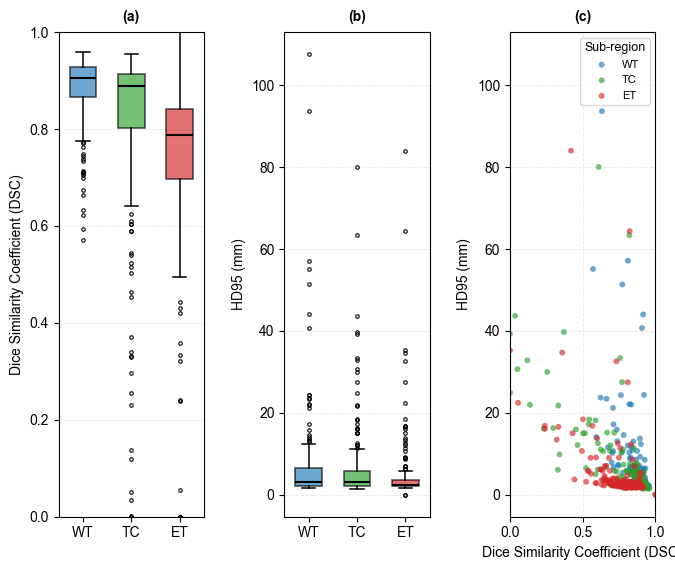


FIGURE 5 SAVED SUCCESSFULLY
PNG : C:\Users\eraze\saved\Fig5_Segmentation_Performance_Native_Space.png
PDF : C:\Users\eraze\saved\Fig5_Segmentation_Performance_Native_Space.pdf
PNG resolution : 600 dpi
Font           : Arial
Font size      : 10 pt
Internal title : REMOVED
Panels         : a, b, c
Output folder  : saved


In [3]:
# ============================================================
# FIGURE 5 — Segmentation performance by tumor sub-region
# Independent test cohort: N = 188
# Native acquisition space
# FINAL PUBLICATION VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# 1. Create output folder
# ============================================================

output_dir = "saved"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# 2. Load FINAL native-space metrics
# ============================================================

csv_file = "Native_Space_Metrics_WT_TC_ET.csv"

df = pd.read_csv(csv_file)

# ============================================================
# 3. Required columns
# ============================================================

required_columns = [
    "Patient",
    "DSC_WT",
    "DSC_TC",
    "DSC_ET",
    "HD95_WT_mm",
    "HD95_TC_mm",
    "HD95_ET_mm"
]

missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ============================================================
# 4. Convert numeric columns
# ============================================================

for col in required_columns:
    if col != "Patient":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["Patient"] = pd.to_numeric(
    df["Patient"],
    errors="coerce"
)

# Remove rows without patient ID
df = df[df["Patient"].notna()].copy()

df["Patient"] = df["Patient"].astype(int)

# ============================================================
# 5. Display final statistics
# ============================================================

print("=" * 75)
print("FIGURE 5 — FINAL NATIVE-SPACE STATISTICS")
print("=" * 75)

print(f"Number of patients: {len(df)}")

print("\nDSC:")
for region in ["WT", "TC", "ET"]:
    values = df[f"DSC_{region}"].dropna()

    print(
        f"{region}: "
        f"Mean = {values.mean():.4f}, "
        f"Median = {values.median():.4f}, "
        f"SD = {values.std(ddof=1):.4f}"
    )

print("\nHD95:")
for region in ["WT", "TC", "ET"]:
    values = df[f"HD95_{region}_mm"].dropna()

    print(
        f"{region}: "
        f"Mean = {values.mean():.4f} mm, "
        f"Median = {values.median():.4f} mm, "
        f"SD = {values.std(ddof=1):.4f} mm"
    )

# ============================================================
# 6. Publication font
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 10

# ============================================================
# 7. Create composite Figure 5
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17.4 / 2.54, 5.8)
)

# ============================================================
# PANEL a — DSC BOXPLOTS
# ============================================================

dsc_data = [
    df["DSC_WT"].dropna(),
    df["DSC_TC"].dropna(),
    df["DSC_ET"].dropna()
]

box_a = axes[0].boxplot(
    dsc_data,
    labels=["WT", "TC", "ET"],
    patch_artist=True,
    widths=0.55,
    medianprops=dict(
        color="black",
        linewidth=1.5
    ),
    boxprops=dict(
        linewidth=1.2
    ),
    whiskerprops=dict(
        linewidth=1.1
    ),
    capprops=dict(
        linewidth=1.1
    ),
    flierprops=dict(
        marker="o",
        markersize=2.5,
        markerfacecolor="none",
        markeredgewidth=0.8
    )
)

# Different colors for WT / TC / ET
panel_a_colors = [
    "#1f77b4",
    "#2ca02c",
    "#d62728"
]

for patch, color in zip(
    box_a["boxes"],
    panel_a_colors
):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

axes[0].set_ylabel(
    "Dice Similarity Coefficient (DSC)",
    fontsize=10
)

axes[0].set_ylim(
    0,
    1.0
)

axes[0].set_title(
    "(a)",
    fontsize=10,
    fontweight="bold",
    pad=8
)

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
    linewidth=0.7
)

# ============================================================
# PANEL b — HD95 BOXPLOTS
# ============================================================

hd95_data = [
    df["HD95_WT_mm"].dropna(),
    df["HD95_TC_mm"].dropna(),
    df["HD95_ET_mm"].dropna()
]

box_b = axes[1].boxplot(
    hd95_data,
    labels=["WT", "TC", "ET"],
    patch_artist=True,
    widths=0.55,
    medianprops=dict(
        color="black",
        linewidth=1.5
    ),
    boxprops=dict(
        linewidth=1.2
    ),
    whiskerprops=dict(
        linewidth=1.1
    ),
    capprops=dict(
        linewidth=1.1
    ),
    flierprops=dict(
        marker="o",
        markersize=2.5,
        markerfacecolor="none",
        markeredgewidth=0.8
    )
)

panel_b_colors = [
    "#1f77b4",
    "#2ca02c",
    "#d62728"
]

for patch, color in zip(
    box_b["boxes"],
    panel_b_colors
):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

axes[1].set_ylabel(
    "HD95 (mm)",
    fontsize=10
)

axes[1].set_title(
    "(b)",
    fontsize=10,
    fontweight="bold",
    pad=8
)

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
    linewidth=0.7
)

# ============================================================
# PANEL c — DSC vs HD95 SCATTER
# ============================================================

regions = {
    "WT": {
        "dsc": "DSC_WT",
        "hd95": "HD95_WT_mm",
        "color": "#1f77b4"
    },
    "TC": {
        "dsc": "DSC_TC",
        "hd95": "HD95_TC_mm",
        "color": "#2ca02c"
    },
    "ET": {
        "dsc": "DSC_ET",
        "hd95": "HD95_ET_mm",
        "color": "#d62728"
    }
}

for region, info in regions.items():

    valid = (
        df[info["dsc"]].notna()
        &
        df[info["hd95"]].notna()
    )

    axes[2].scatter(
        df.loc[valid, info["dsc"]],
        df.loc[valid, info["hd95"]],
        s=18,
        alpha=0.65,
        label=region,
        color=info["color"],
        edgecolors="none"
    )

axes[2].set_xlabel(
    "Dice Similarity Coefficient (DSC)",
    fontsize=10
)

axes[2].set_ylabel(
    "HD95 (mm)",
    fontsize=10
)

axes[2].set_xlim(
    0,
    1.0
)

axes[2].set_title(
    "(c)",
    fontsize=10,
    fontweight="bold",
    pad=8
)

axes[2].grid(
    True,
    linestyle="--",
    alpha=0.25,
    linewidth=0.7
)

axes[2].legend(
    title="Sub-region",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    loc="upper right"
)

# ============================================================
# 8. Final composite layout
# ============================================================

plt.tight_layout(
    w_pad=2.0
)

# ============================================================
# 9. Save Figure 5
# ============================================================

png_file = os.path.join(
    output_dir,
    "Fig5_Segmentation_Performance_Native_Space.png"
)

pdf_file = os.path.join(
    output_dir,
    "Fig5_Segmentation_Performance_Native_Space.pdf"
)

# ------------------------------------------------------------
# PNG — 600 dpi
# ------------------------------------------------------------

plt.savefig(
    png_file,
    dpi=600,
    bbox_inches="tight"
)

# ------------------------------------------------------------
# PDF — vector format
# ------------------------------------------------------------

plt.savefig(
    pdf_file,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 10. Confirmation
# ============================================================

print("\n" + "=" * 75)
print("FIGURE 5 SAVED SUCCESSFULLY")
print("=" * 75)

print(f"PNG : {os.path.abspath(png_file)}")
print(f"PDF : {os.path.abspath(pdf_file)}")
print("PNG resolution : 600 dpi")
print("Font           : Arial")
print("Font size      : 10 pt")
print("Internal title : REMOVED")
print("Panels         : a, b, c")
print("Output folder  : saved")
print("=" * 75)

## 11. Qualitative Publication Figures

Axial/Coronal/Sagittal slices at 600 DPI, no header — showing FLAIR, Ground Truth, and the model's prediction side by side.

### Patients 75 and 53



PATIENT 75
Best Axial slice: 76


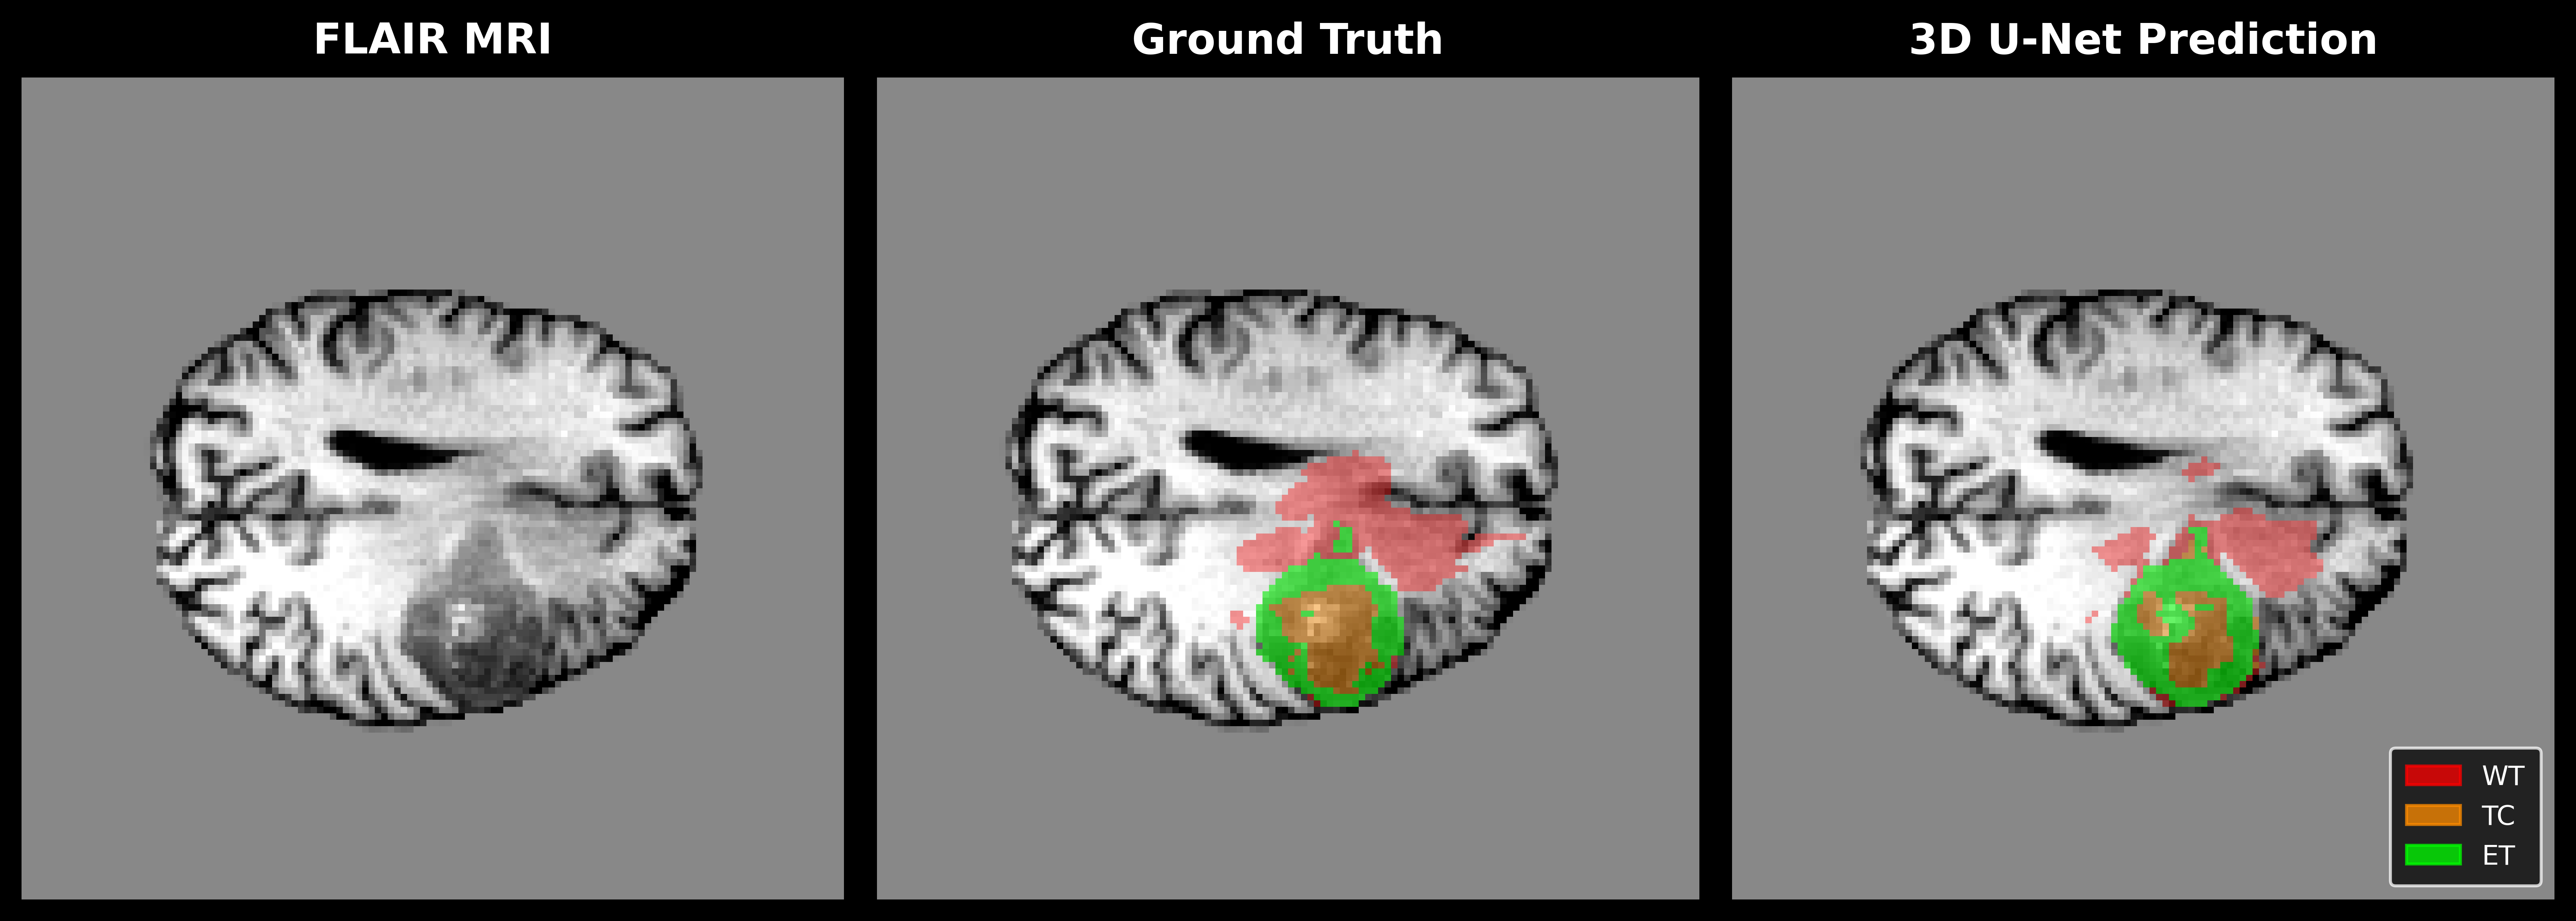

Saved: C:\Users\eraze\Saved\Patient_75_Axial_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_75_Axial.pdf
Best Coronal slice: 72


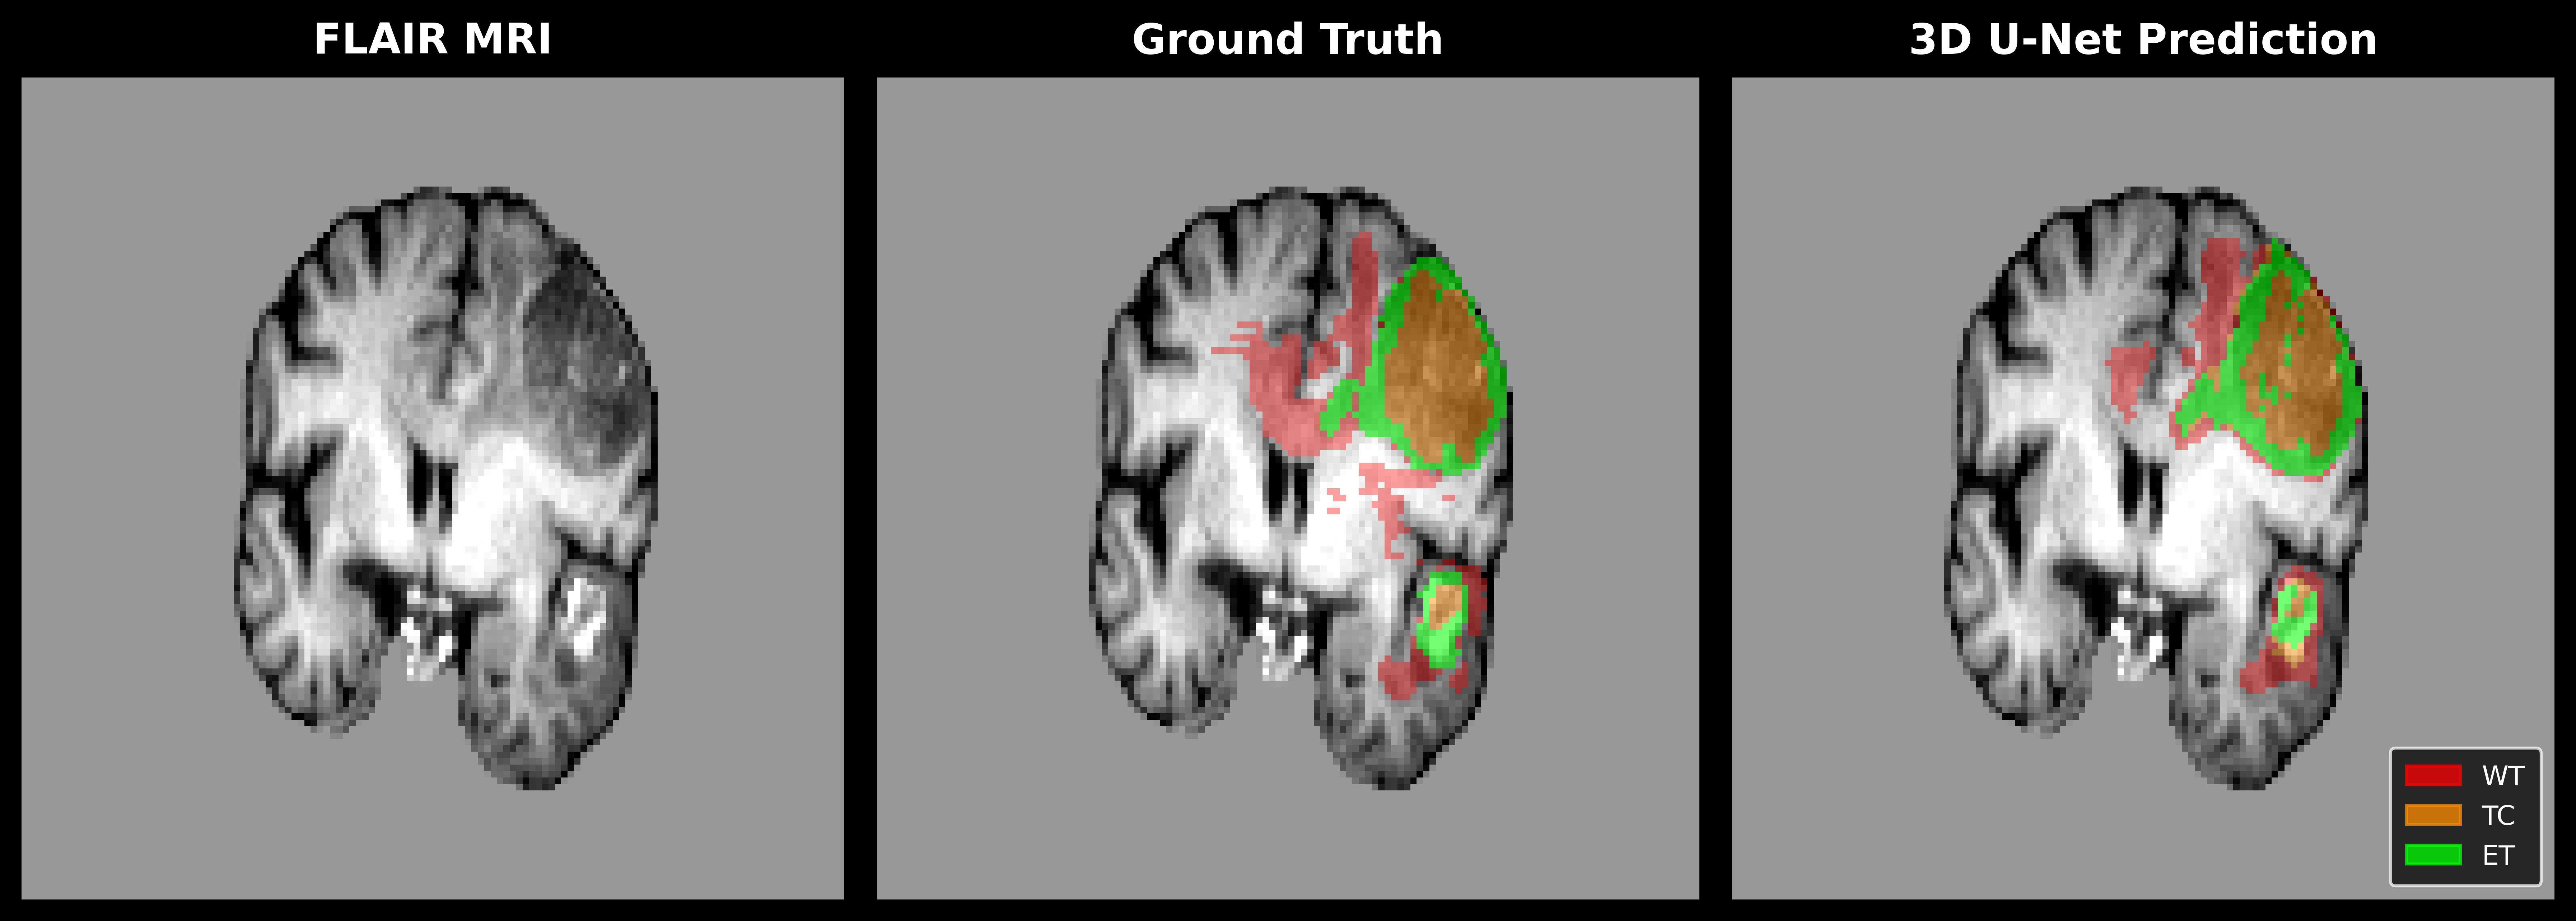

Saved: C:\Users\eraze\Saved\Patient_75_Coronal_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_75_Coronal.pdf
Best Sagittal slice: 76


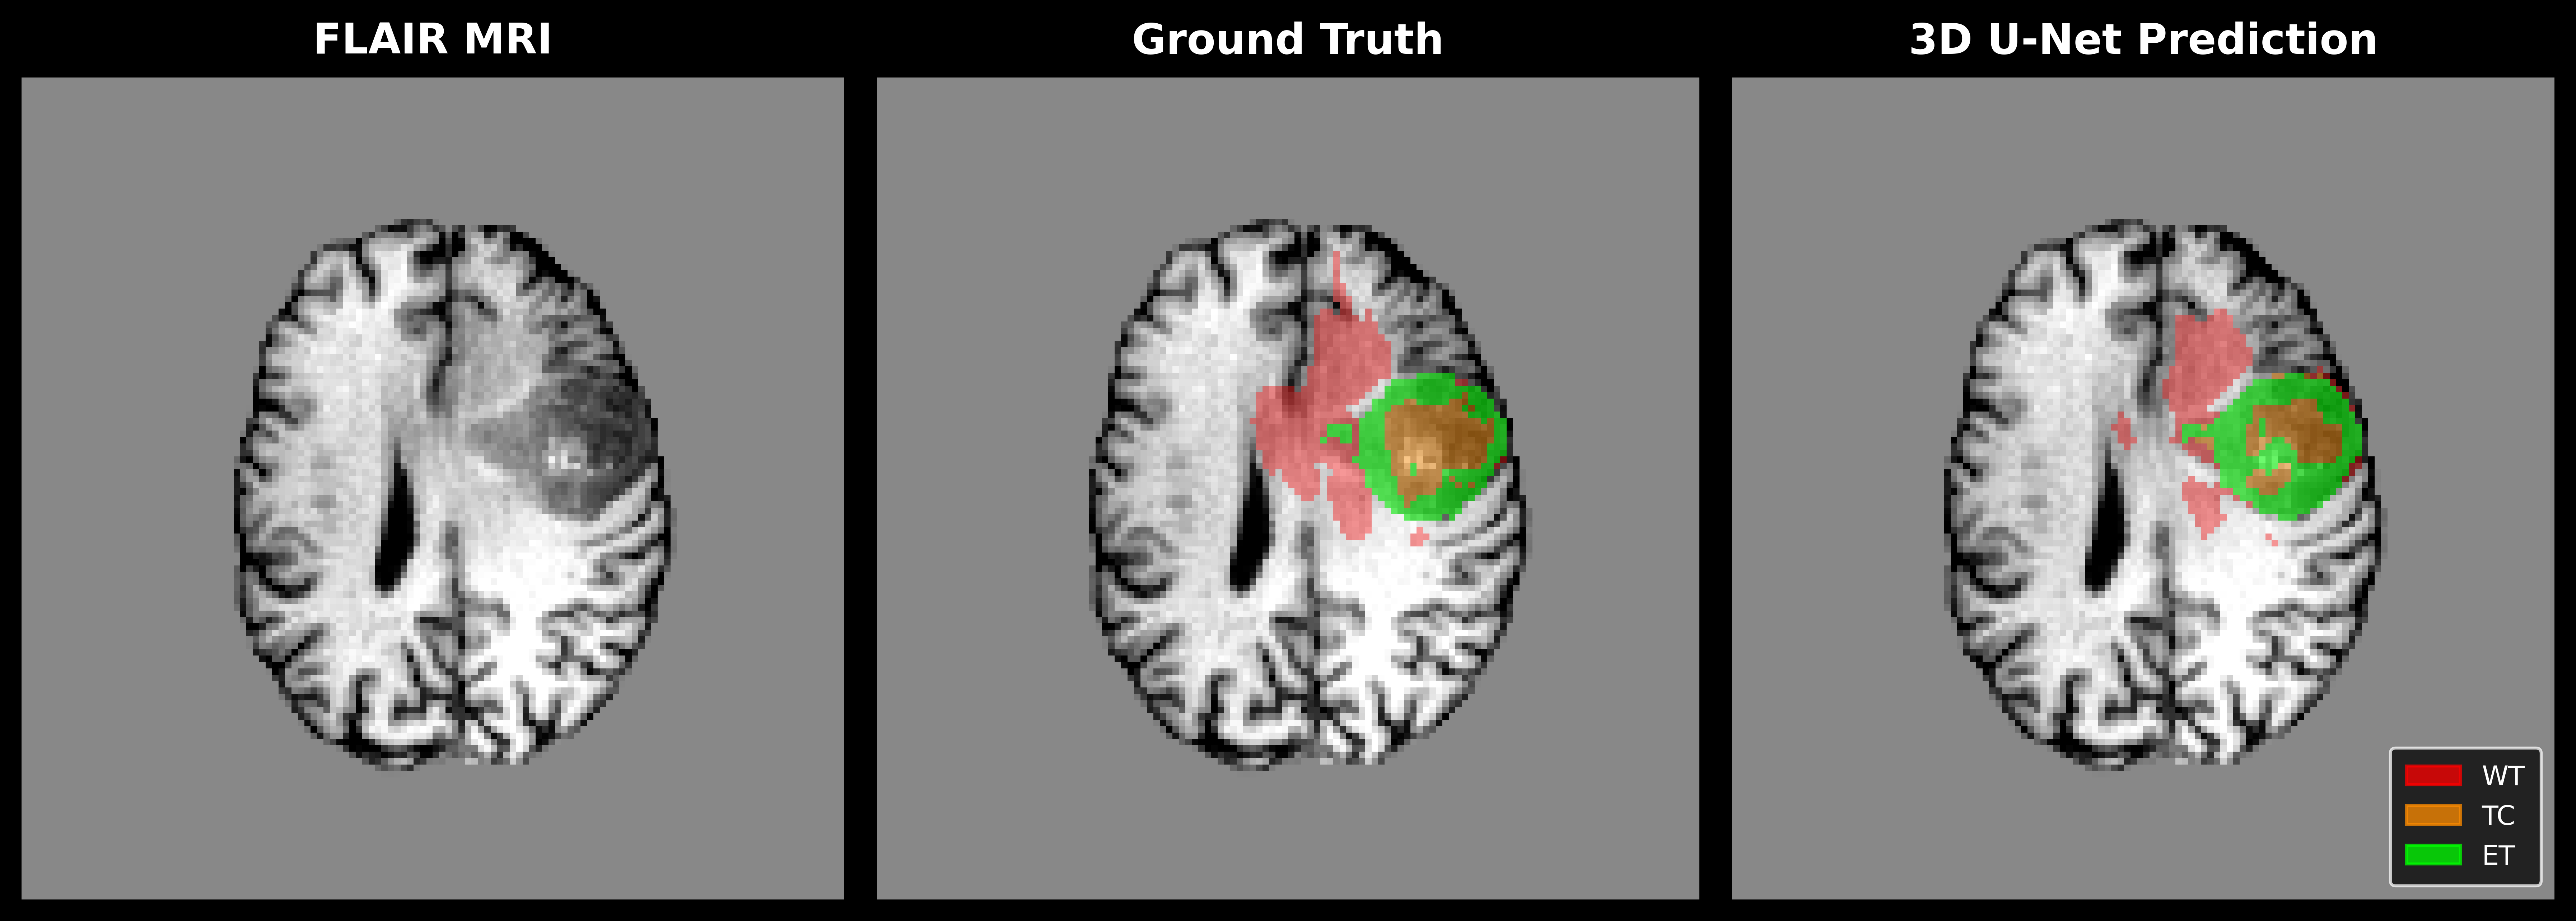

Saved: C:\Users\eraze\Saved\Patient_75_Sagittal_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_75_Sagittal.pdf


PATIENT 53
Best Axial slice: 43


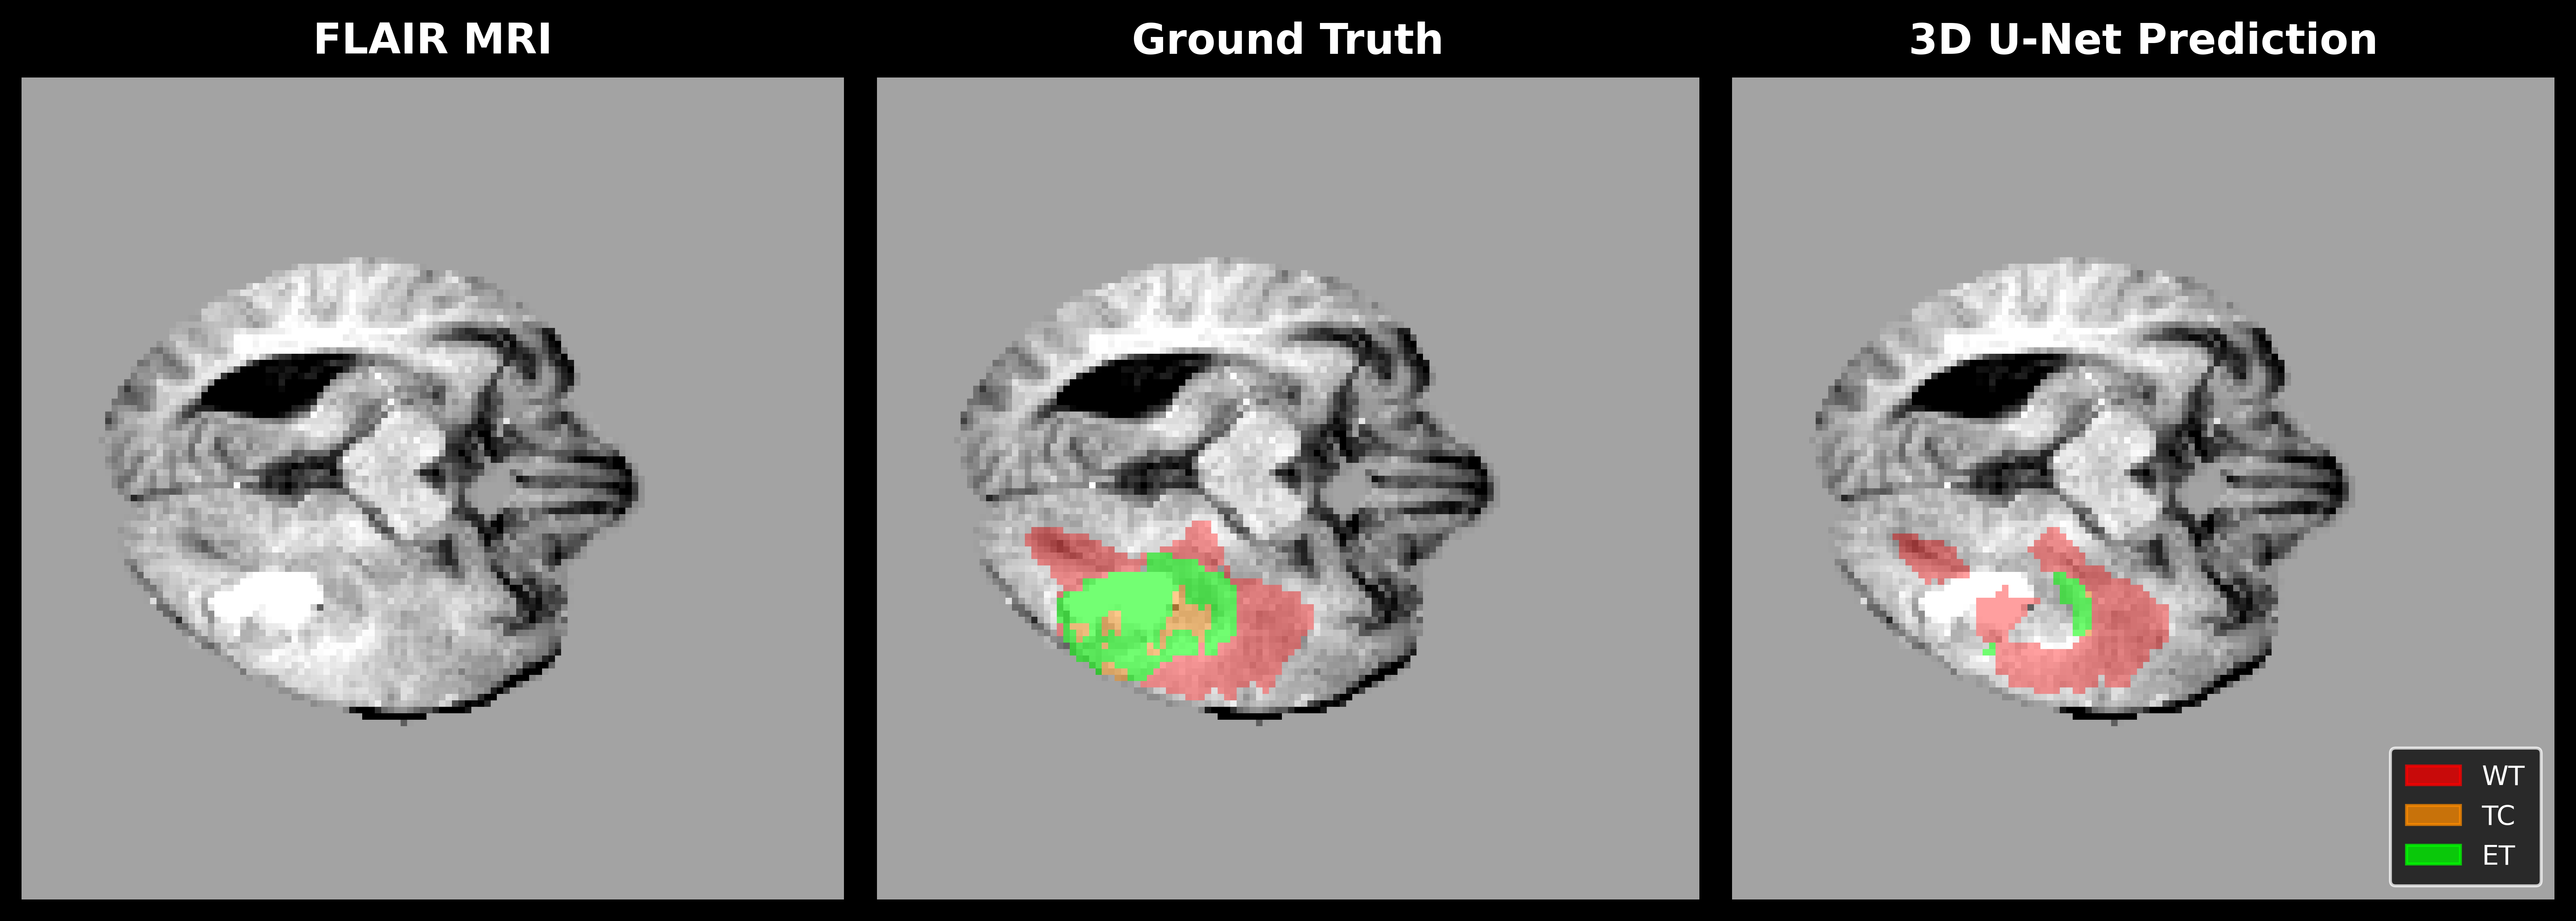

Saved: C:\Users\eraze\Saved\Patient_53_Axial_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_53_Axial.pdf
Best Coronal slice: 39


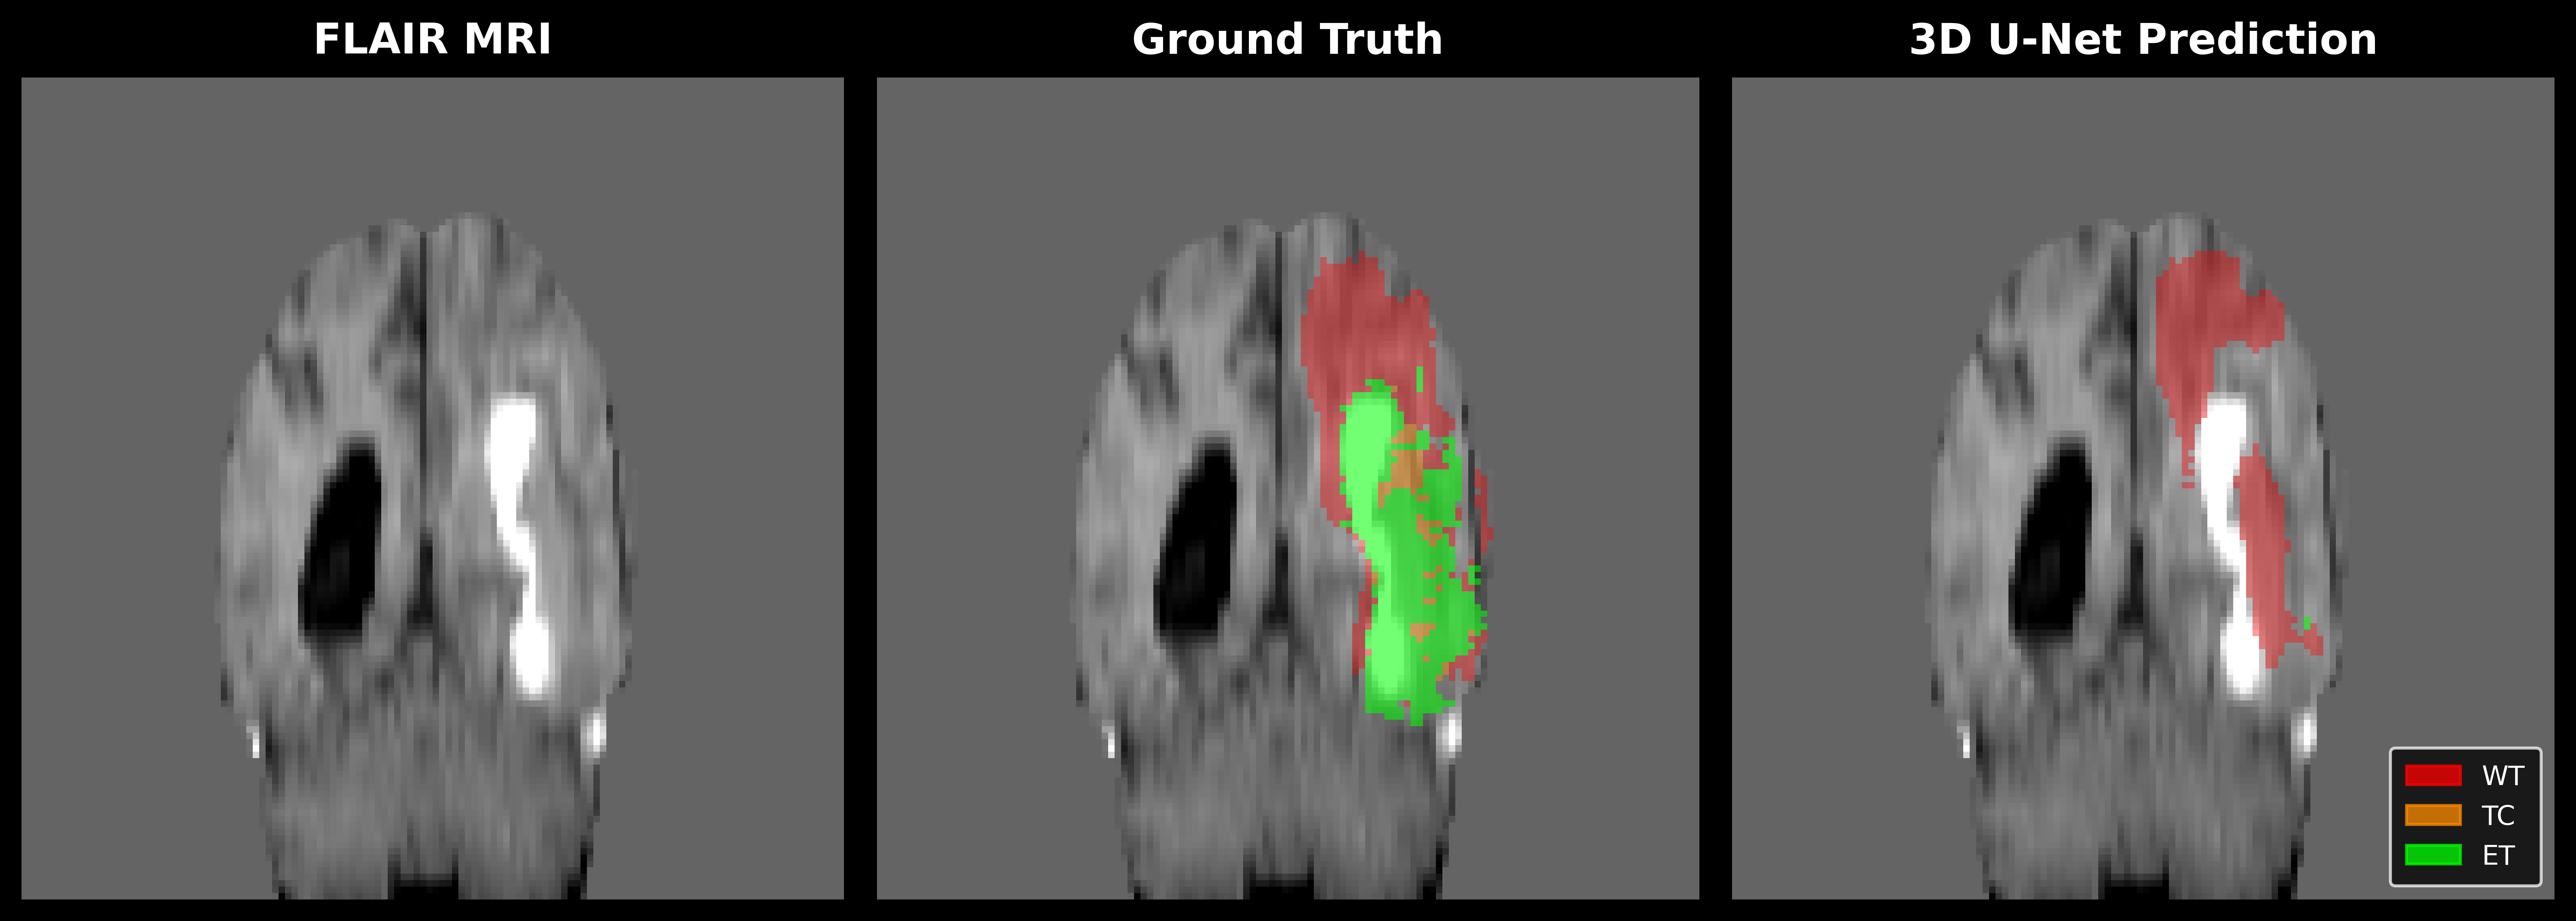

Saved: C:\Users\eraze\Saved\Patient_53_Coronal_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_53_Coronal.pdf
Best Sagittal slice: 43


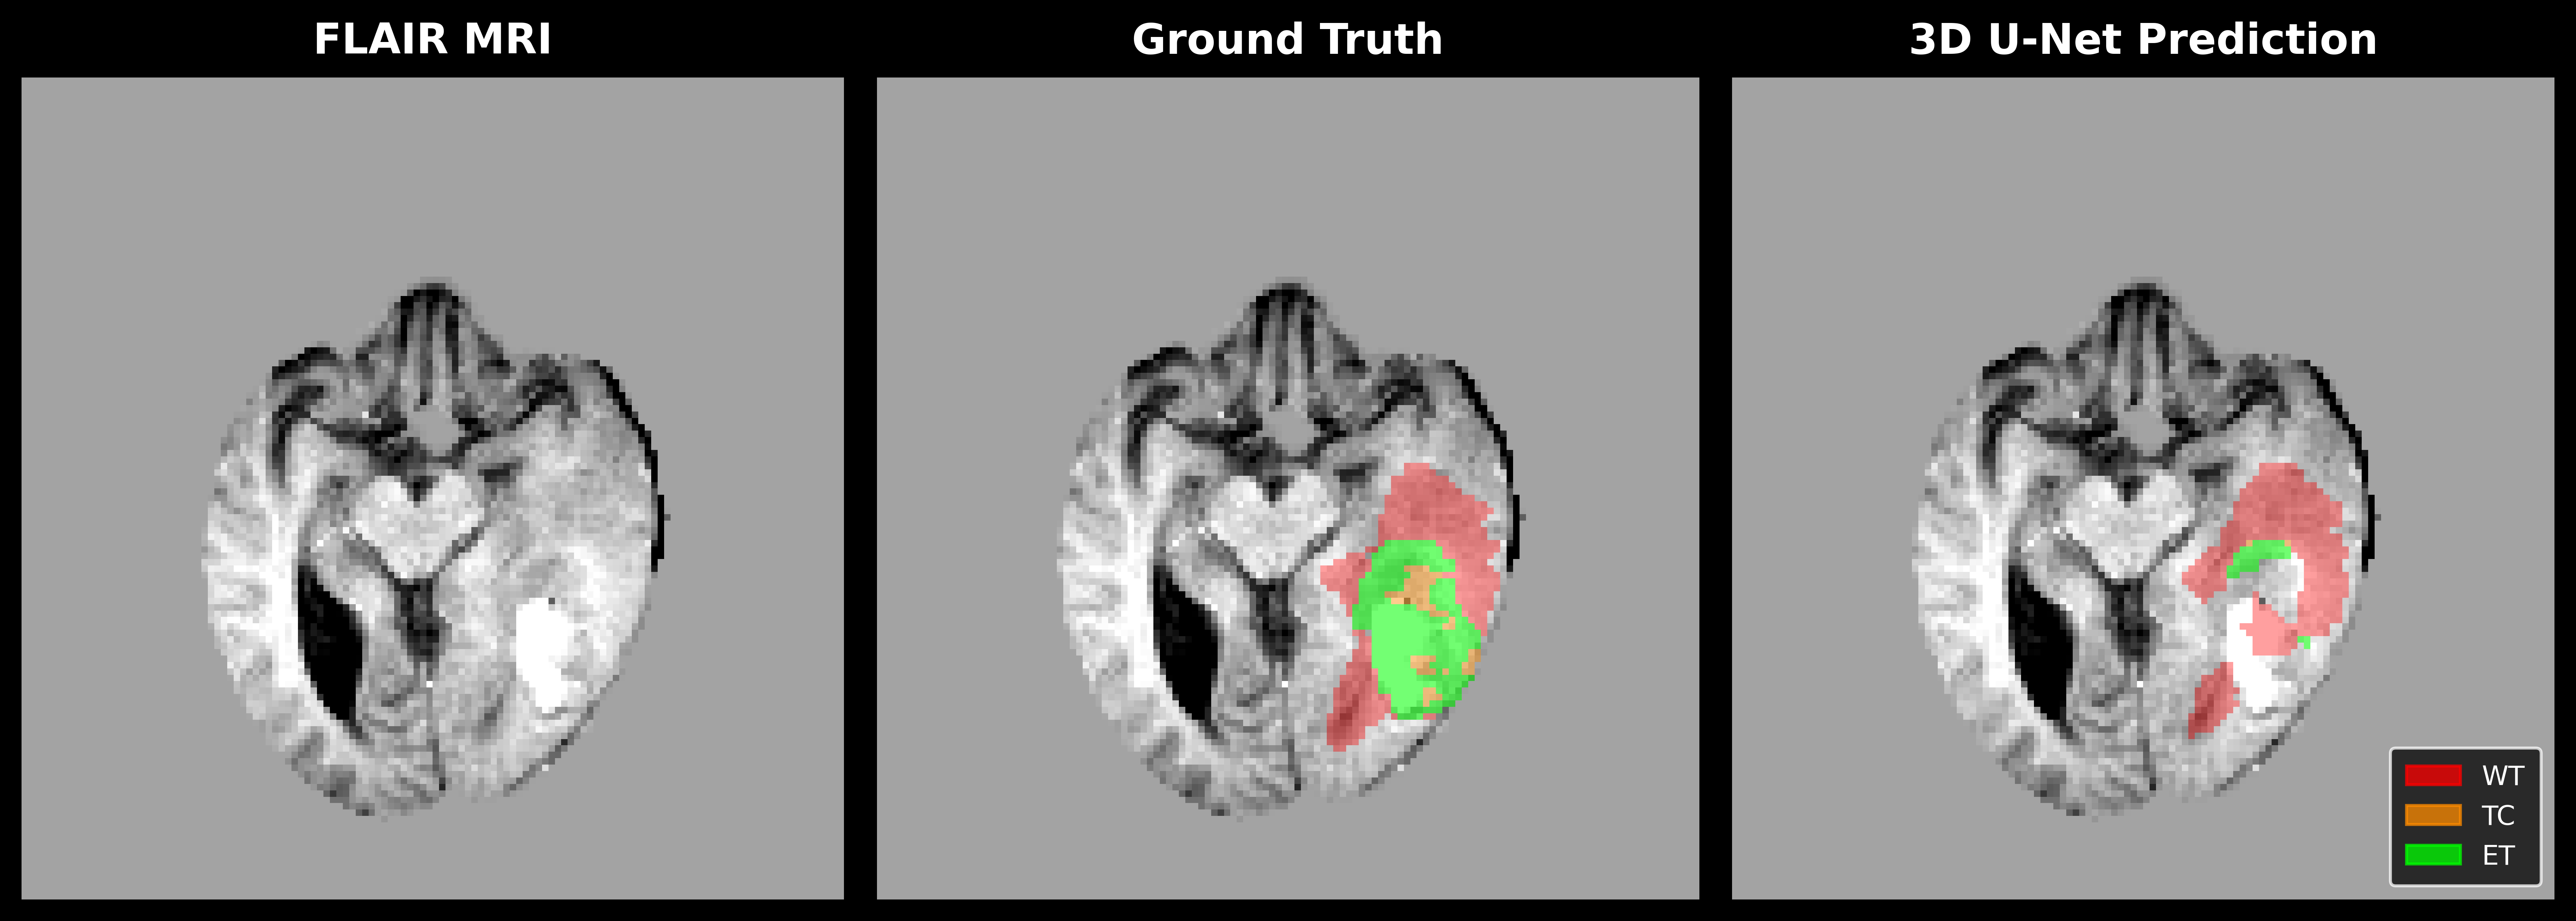

Saved: C:\Users\eraze\Saved\Patient_53_Sagittal_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_53_Sagittal.pdf


ALL FIGURES COMPLETED

Patient 75:
  Saved/Patient_75_Axial_600dpi.png
  Saved/Patient_75_Axial.pdf
  Saved/Patient_75_Coronal_600dpi.png
  Saved/Patient_75_Coronal.pdf
  Saved/Patient_75_Sagittal_600dpi.png
  Saved/Patient_75_Sagittal.pdf

Patient 53:
  Saved/Patient_53_Axial_600dpi.png
  Saved/Patient_53_Axial.pdf
  Saved/Patient_53_Coronal_600dpi.png
  Saved/Patient_53_Coronal.pdf
  Saved/Patient_53_Sagittal_600dpi.png
  Saved/Patient_53_Sagittal.pdf



In [84]:
# ============================================================
# PUBLICATION-QUALITY FIGURES
# PATIENTS 75 & 53
# AXIAL + CORONAL + SAGITTAL
#
# 600 DPI
# NO PATIENT / DSC / HD95 HEADER
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

os.makedirs("Saved", exist_ok=True)

# ============================================================
# 2. PATIENTS TO DISPLAY
# ============================================================

patient_numbers = [75, 53]

# ============================================================
# 3. PUBLICATION COLORS
# ============================================================

mask_cmap = ListedColormap([
    (0.0, 0.0, 0.0, 0.0),    # Background
    (1.0, 0.0, 0.0, 0.38),    # WT
    (1.0, 0.55, 0.0, 0.45),   # TC
    (0.0, 1.0, 0.0, 0.55)     # ET
])

# ============================================================
# 4. LEGEND
# ============================================================

legend_elements = [

    Patch(
        facecolor="#FF0000",
        edgecolor="#FF0000",
        alpha=0.75,
        label="WT"
    ),

    Patch(
        facecolor="#FF8C00",
        edgecolor="#FF8C00",
        alpha=0.75,
        label="TC"
    ),

    Patch(
        facecolor="#00FF00",
        edgecolor="#00FF00",
        alpha=0.75,
        label="ET"
    )
]

# ============================================================
# 5. CONVERT BRATS MULTI-CHANNEL MASK
#    INTO ONE LABEL MAP
#
#    0 = Background
#    1 = WT
#    2 = TC
#    3 = ET
# ============================================================

def make_label_map(mask, spatial_shape):

    label_map = np.zeros(
        spatial_shape,
        dtype=np.uint8
    )

    # --------------------------------------------------------
    # ET
    # --------------------------------------------------------

    if mask.shape[0] >= 3:

        label_map[
            mask[2] > 0
        ] = 3

    # --------------------------------------------------------
    # TC
    # --------------------------------------------------------

    if mask.shape[0] >= 2:

        tc_mask = mask[1] > 0

        label_map[
            tc_mask & (label_map == 0)
        ] = 2

    # --------------------------------------------------------
    # WT
    # --------------------------------------------------------

    if mask.shape[0] >= 1:

        wt_mask = mask[0] > 0

        label_map[
            wt_mask & (label_map == 0)
        ] = 1

    return label_map


# ============================================================
# 6. AUTOMATIC BRAIN CROP
# ============================================================

def crop_brain(
    flair_view,
    gt_view,
    pred_view
):

    brain_mask = (
        flair_view >
        flair_view.max() * 0.02
    )

    ys, xs = np.where(
        brain_mask
    )

    if len(xs) == 0:

        return (
            flair_view,
            gt_view,
            pred_view
        )

    x_min = xs.min()
    x_max = xs.max()

    y_min = ys.min()
    y_max = ys.max()

    # Small margin
    margin = 4

    x_min = max(
        0,
        x_min - margin
    )

    x_max = min(
        flair_view.shape[1] - 1,
        x_max + margin
    )

    y_min = max(
        0,
        y_min - margin
    )

    y_max = min(
        flair_view.shape[0] - 1,
        y_max + margin
    )

    return (

        flair_view[
            y_min:y_max + 1,
            x_min:x_max + 1
        ],

        gt_view[
            y_min:y_max + 1,
            x_min:x_max + 1
        ],

        pred_view[
            y_min:y_max + 1,
            x_min:x_max + 1
        ]
    )


# ============================================================
# 7. CREATE ONE VIEW
#
#    IMPORTANT:
#    NO PATIENT NAME
#    NO DSC
#    NO HD95
# ============================================================

def create_view(
    flair_view,
    gt_view,
    pred_view,
    plane_name,
    patient_number
):

    # --------------------------------------------------------
    # Crop only empty background
    # --------------------------------------------------------

    (
        flair_view,
        gt_view,
        pred_view
    ) = crop_brain(
        flair_view,
        gt_view,
        pred_view
    )

    # --------------------------------------------------------
    # MRI intensity
    # --------------------------------------------------------

    vmin = np.percentile(
        flair_view,
        1
    )

    vmax = np.percentile(
        flair_view,
        99
    )

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12.0, 4.7),
        dpi=600,
        facecolor="black"
    )

    for ax in axes:
        ax.set_facecolor("black")

    H, W = flair_view.shape

    extent = [
        0,
        W,
        H,
        0
    ]

    # ========================================================
    # FLAIR
    # ========================================================

    axes[0].imshow(
        flair_view,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[0].set_title(
        "FLAIR MRI",
        color="white",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # ========================================================
    # GROUND TRUTH
    # ========================================================

    axes[1].imshow(
        flair_view,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[1].imshow(
        gt_view,
        cmap=mask_cmap,
        vmin=0,
        vmax=3,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[1].set_title(
        "Ground Truth",
        color="white",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # ========================================================
    # PREDICTION
    # ========================================================

    axes[2].imshow(
        flair_view,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[2].imshow(
        pred_view,
        cmap=mask_cmap,
        vmin=0,
        vmax=3,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[2].set_title(
        "3D U-Net Prediction",
        color="white",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # ========================================================
    # KEEP BRAIN PROPORTIONS
    # ========================================================

    for ax in axes:

        ax.set_xlim(
            0,
            W
        )

        ax.set_ylim(
            H,
            0
        )

        ax.set_aspect(
            "equal",
            adjustable="box"
        )

        ax.axis("off")

    # ========================================================
    # LEGEND
    # ========================================================

    legend = axes[2].legend(
        handles=legend_elements,
        loc="lower right",
        fontsize=9,
        frameon=True,
        facecolor="black",
        edgecolor="white",
        framealpha=0.75,
        borderpad=0.6
    )

    for text in legend.get_texts():
        text.set_color("white")

    # ========================================================
    # IMPORTANT:
    # NO GLOBAL TITLE
    # NO PATIENT NUMBER
    # NO DSC
    # NO HD95
    # ========================================================

    # ========================================================
    # LAYOUT
    # ========================================================

    plt.subplots_adjust(
        left=0.01,
        right=0.99,
        top=0.99,
        bottom=0.01,
        wspace=0.04
    )

    # ========================================================
    # SAVE
    # ========================================================

    png_path = (
        f"Saved/"
        f"Patient_{patient_number}_"
        f"{plane_name}_600dpi.png"
    )

    pdf_path = (
        f"Saved/"
        f"Patient_{patient_number}_"
        f"{plane_name}.pdf"
    )

    plt.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight",
        facecolor="black",
        pad_inches=0.02
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="black",
        pad_inches=0.02
    )

    plt.show()

    print(
        f"Saved: {os.path.abspath(png_path)}"
    )

    print(
        f"Saved: {os.path.abspath(pdf_path)}"
    )


# ============================================================
# 8. PROCESS PATIENTS
# ============================================================

model.eval()

for patient_number in patient_numbers:

    print("\n")
    print("============================================")
    print(f"PATIENT {patient_number}")
    print("============================================")

    # --------------------------------------------------------
    # Load patient
    # --------------------------------------------------------

    sample = test_loader.dataset[
        patient_number - 1
    ]

    image = (
        sample["image"]
        .unsqueeze(0)
        .to(device)
    )

    label = (
        sample["label"]
        .unsqueeze(0)
        .to(device)
    )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    with torch.no_grad():

        output = model(image)

    prediction = (
        torch.sigmoid(output) > 0.5
    ).float()

    pred_np = (
        prediction[0]
        .cpu()
        .numpy()
    )

    gt_np = (
        label[0]
        .cpu()
        .numpy()
    )

    # --------------------------------------------------------
    # FLAIR
    # --------------------------------------------------------

    flair = (
        image[0, 0]
        .detach()
        .cpu()
        .numpy()
    )

    flair = (
        flair - flair.min()
    ) / (
        flair.max() - flair.min() + 1e-8
    )

    # --------------------------------------------------------
    # Label maps
    # --------------------------------------------------------

    gt_label = make_label_map(
        gt_np,
        flair.shape
    )

    pred_label = make_label_map(
        pred_np,
        flair.shape
    )

    # --------------------------------------------------------
    # Combined mask
    # --------------------------------------------------------

    combined = np.maximum(
        gt_label,
        pred_label
    )

    # ========================================================
    # AXIAL
    # ========================================================

    axial_score = combined.sum(
        axis=(0, 1)
    )

    z = int(
        np.argmax(axial_score)
    )

    print(
        f"Best Axial slice: {z}"
    )

    flair_axial = flair[:, :, z]
    gt_axial = gt_label[:, :, z]
    pred_axial = pred_label[:, :, z]

    create_view(
        flair_axial,
        gt_axial,
        pred_axial,
        "Axial",
        patient_number
    )

    # ========================================================
    # CORONAL
    # ========================================================

    coronal_score = combined.sum(
        axis=(0, 2)
    )

    y = int(
        np.argmax(coronal_score)
    )

    print(
        f"Best Coronal slice: {y}"
    )

    flair_coronal = flair[:, y, :]
    gt_coronal = gt_label[:, y, :]
    pred_coronal = pred_label[:, y, :]

    # Rotate for anatomical display
    flair_coronal = np.rot90(
        flair_coronal
    )

    gt_coronal = np.rot90(
        gt_coronal
    )

    pred_coronal = np.rot90(
        pred_coronal
    )

    create_view(
        flair_coronal,
        gt_coronal,
        pred_coronal,
        "Coronal",
        patient_number
    )

    # ========================================================
    # SAGITTAL
    # ========================================================

    sagittal_score = combined.sum(
        axis=(0, 1)
    )

    x = int(
        np.argmax(sagittal_score)
    )

    print(
        f"Best Sagittal slice: {x}"
    )

    flair_sagittal = flair[:, :, x]
    gt_sagittal = gt_label[:, :, x]
    pred_sagittal = pred_label[:, :, x]

    # Rotate for anatomical display
    flair_sagittal = np.rot90(
        flair_sagittal
    )

    gt_sagittal = np.rot90(
        gt_sagittal
    )

    pred_sagittal = np.rot90(
        pred_sagittal
    )

    create_view(
        flair_sagittal,
        gt_sagittal,
        pred_sagittal,
        "Sagittal",
        patient_number
    )


# ============================================================
# 9. FINAL OUTPUT
# ============================================================

print("\n")
print("============================================")
print("ALL FIGURES COMPLETED")
print("============================================")

print("""
Patient 75:
  Saved/Patient_75_Axial_600dpi.png
  Saved/Patient_75_Axial.pdf
  Saved/Patient_75_Coronal_600dpi.png
  Saved/Patient_75_Coronal.pdf
  Saved/Patient_75_Sagittal_600dpi.png
  Saved/Patient_75_Sagittal.pdf

Patient 53:
  Saved/Patient_53_Axial_600dpi.png
  Saved/Patient_53_Axial.pdf
  Saved/Patient_53_Coronal_600dpi.png
  Saved/Patient_53_Coronal.pdf
  Saved/Patient_53_Sagittal_600dpi.png
  Saved/Patient_53_Sagittal.pdf
""")

### Patient 173

Best Axial slice: 60


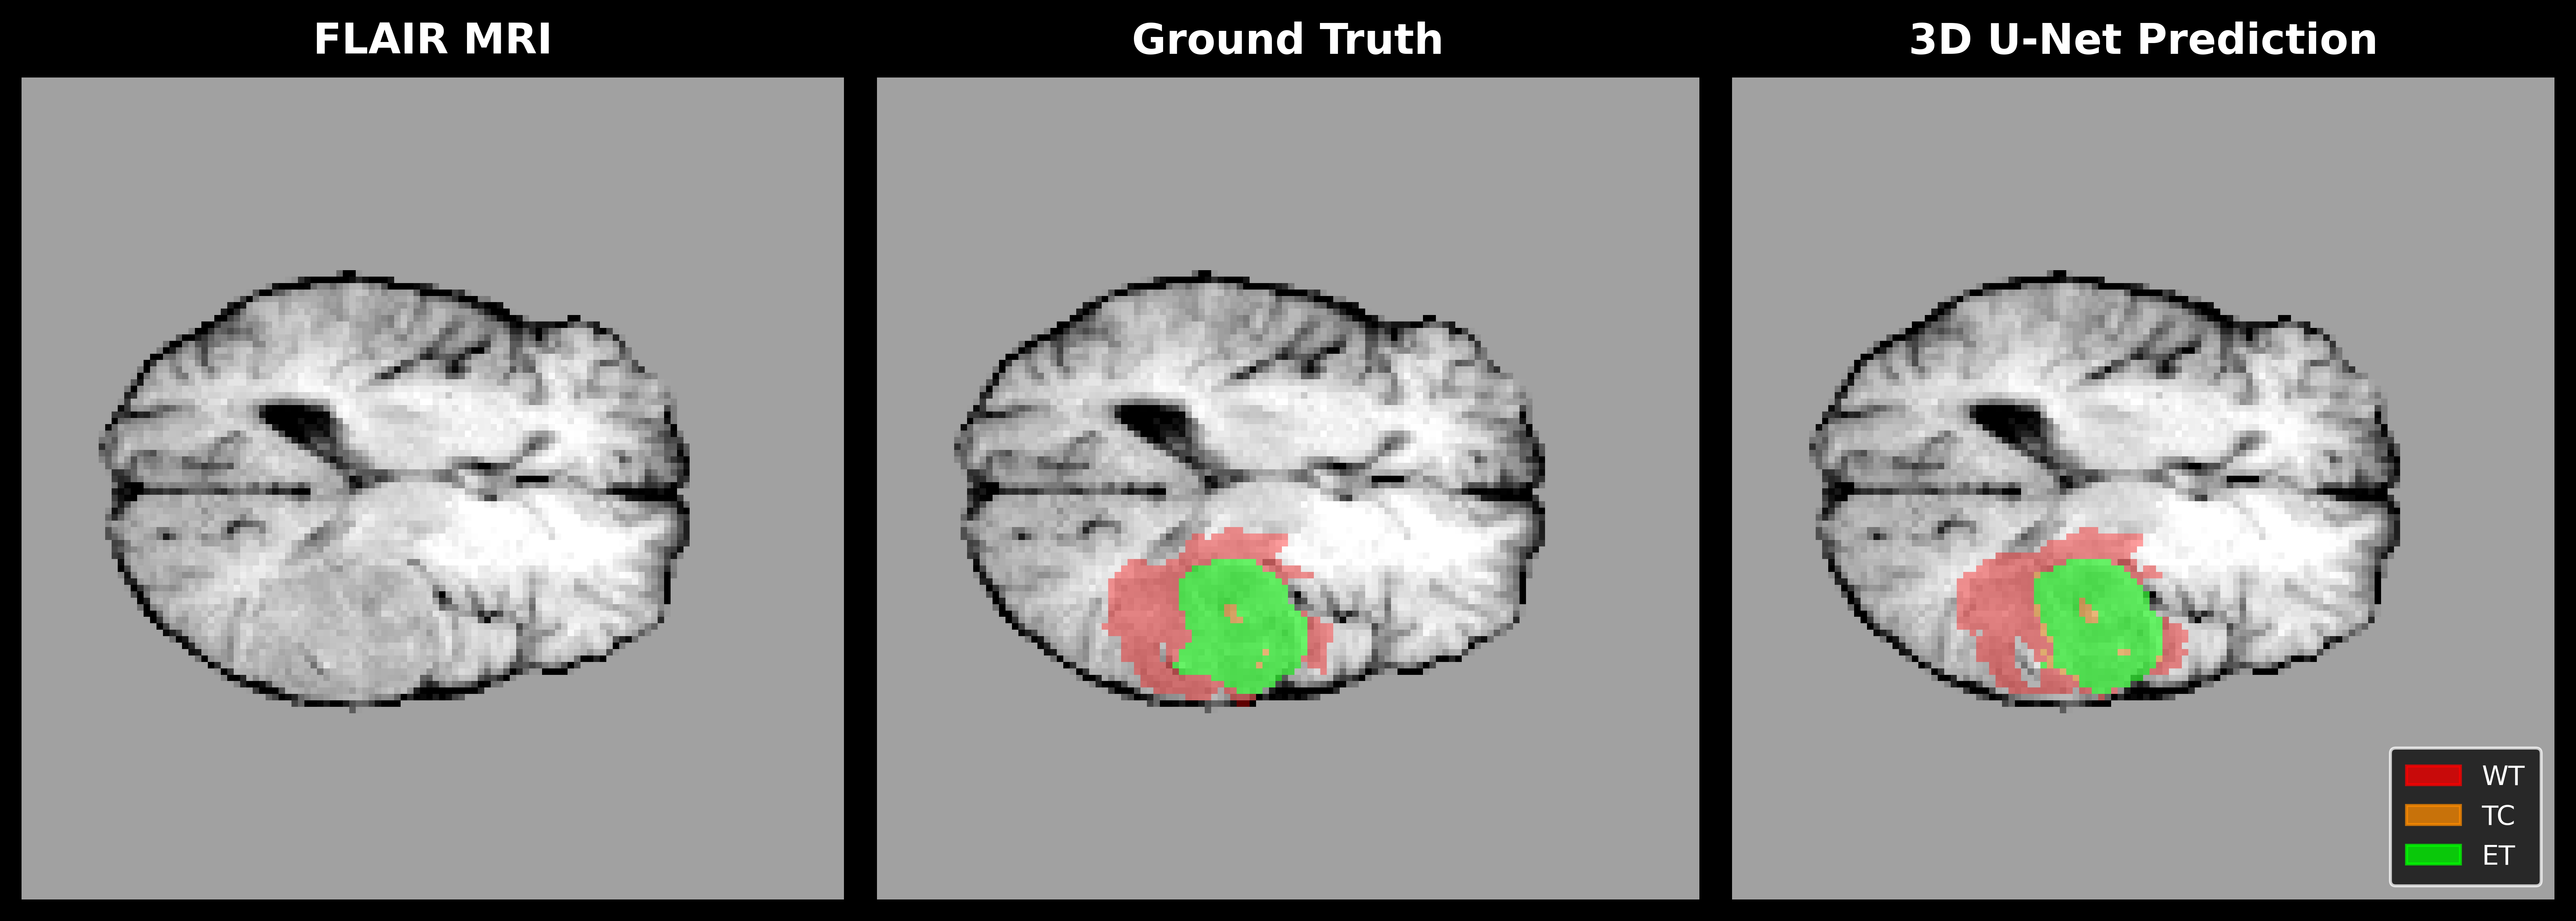

Saved: C:\Users\eraze\Saved\Patient_173_Axial_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_173_Axial.pdf
Best Coronal slice: 54


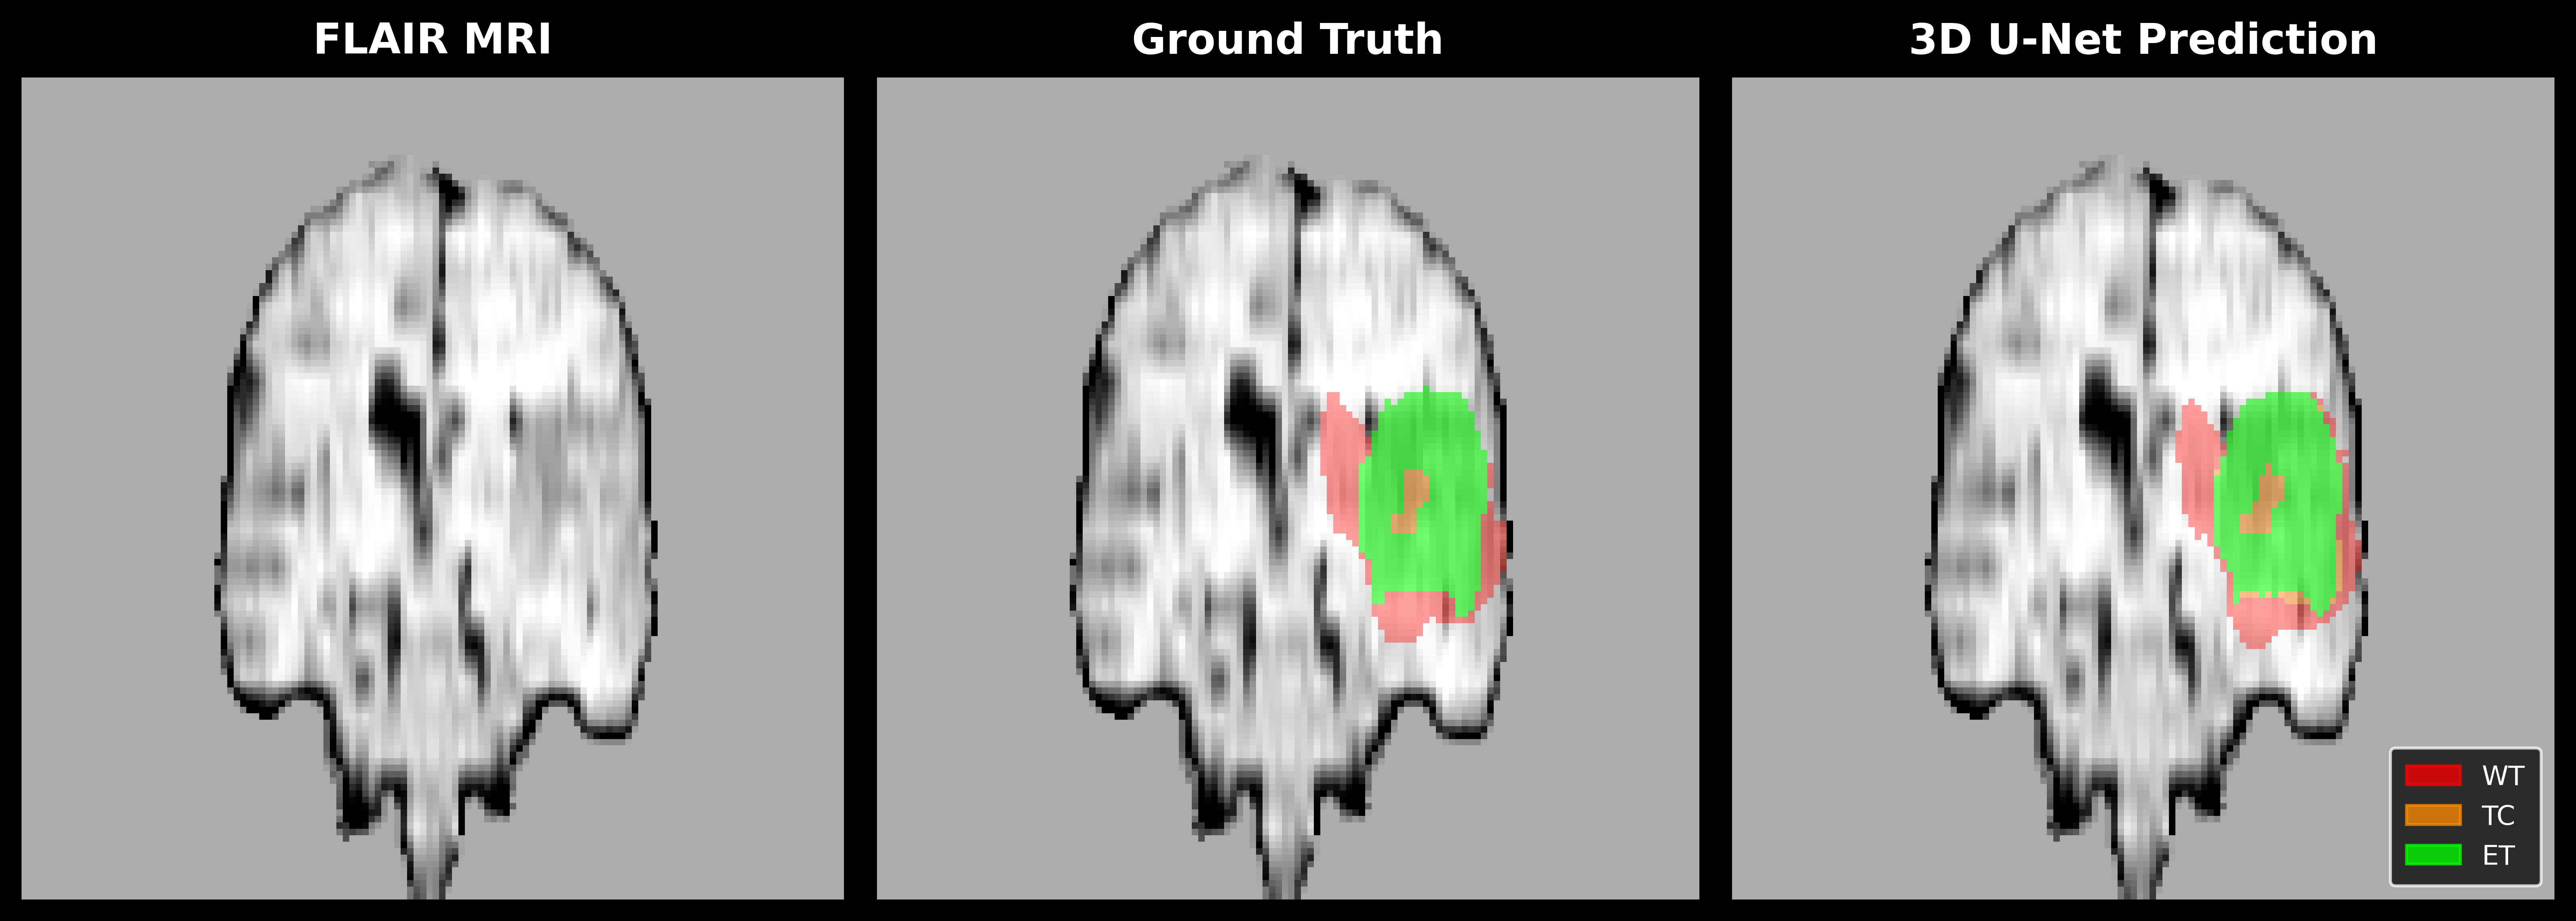

Saved: C:\Users\eraze\Saved\Patient_173_Coronal_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_173_Coronal.pdf
Best Sagittal slice: 60


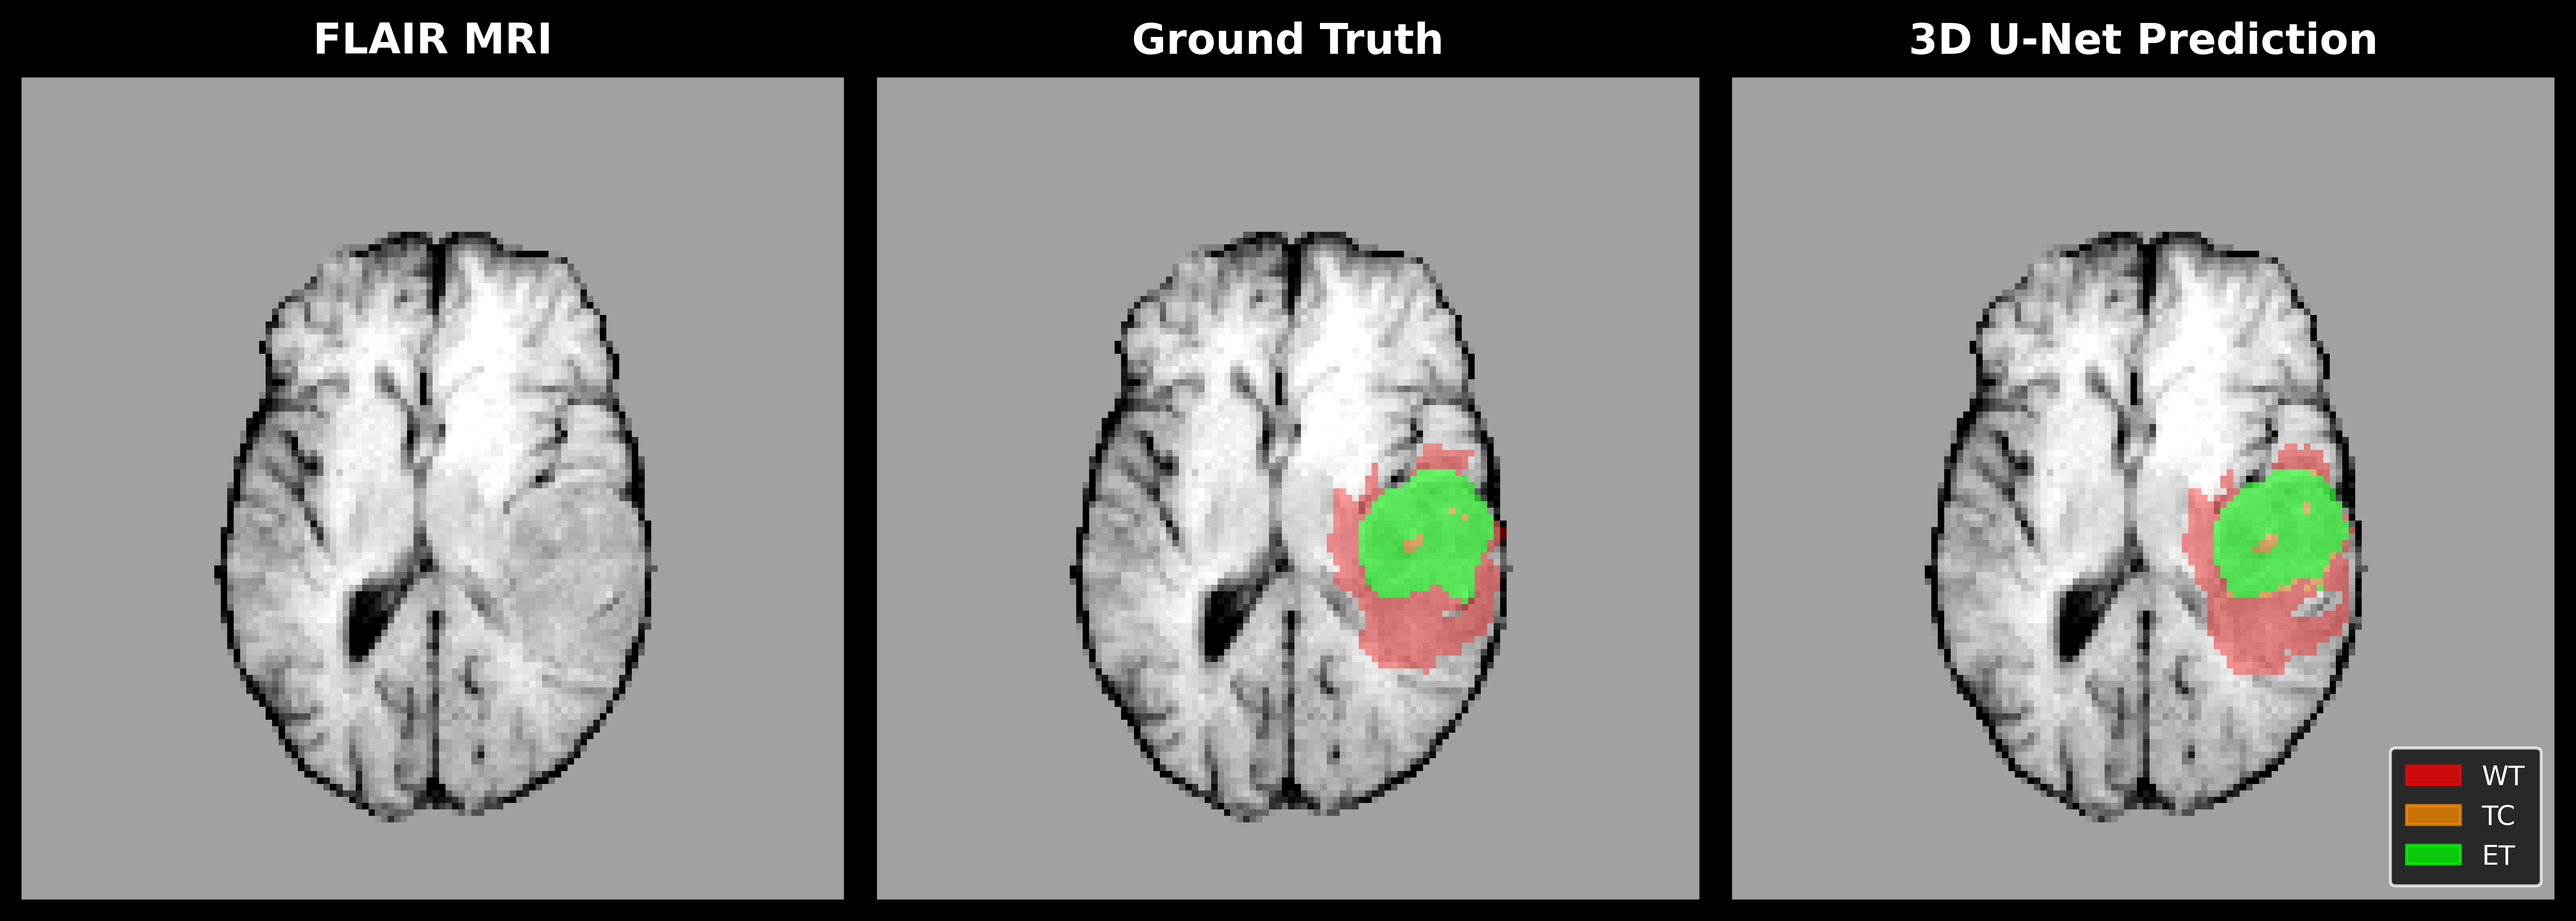

Saved: C:\Users\eraze\Saved\Patient_173_Sagittal_600dpi.png
Saved: C:\Users\eraze\Saved\Patient_173_Sagittal.pdf

PATIENT 173 COMPLETED — NO HEADER


In [85]:
# ============================================================
# PATIENT 173 — NO HEADER
# AXIAL + CORONAL + SAGITTAL
# 600 DPI
# ============================================================

patient_number = 173

# ------------------------------------------------------------
# Load patient
# ------------------------------------------------------------

model.eval()

sample = test_loader.dataset[
    patient_number - 1
]

image = sample["image"].unsqueeze(0).to(device)
label = sample["label"].unsqueeze(0).to(device)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

with torch.no_grad():
    output = model(image)

prediction = (
    torch.sigmoid(output) > 0.5
).float()

pred_np = prediction[0].cpu().numpy()
gt_np = label[0].cpu().numpy()

# ------------------------------------------------------------
# FLAIR
# ------------------------------------------------------------

flair = (
    image[0, 0]
    .detach()
    .cpu()
    .numpy()
)

flair = (
    flair - flair.min()
) / (
    flair.max() - flair.min() + 1e-8
)

# ------------------------------------------------------------
# Label maps
# ------------------------------------------------------------

gt_label = make_label_map(
    gt_np,
    flair.shape
)

pred_label = make_label_map(
    pred_np,
    flair.shape
)

combined = np.maximum(
    gt_label,
    pred_label
)

# ============================================================
# FUNCTION: SAVE ONE PLANE
# ============================================================

def save_patient_173_plane(
    flair_view,
    gt_view,
    pred_view,
    plane_name
):

    # --------------------------------------------------------
    # Crop background
    # --------------------------------------------------------

    (
        flair_view,
        gt_view,
        pred_view
    ) = crop_brain(
        flair_view,
        gt_view,
        pred_view
    )

    # --------------------------------------------------------
    # Intensity
    # --------------------------------------------------------

    vmin = np.percentile(
        flair_view,
        1
    )

    vmax = np.percentile(
        flair_view,
        99
    )

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12.0, 4.7),
        dpi=600,
        facecolor="black"
    )

    for ax in axes:
        ax.set_facecolor("black")

    H, W = flair_view.shape

    extent = [
        0,
        W,
        H,
        0
    ]

    # ========================================================
    # FLAIR
    # ========================================================

    axes[0].imshow(
        flair_view,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[0].set_title(
        "FLAIR MRI",
        color="white",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # ========================================================
    # GROUND TRUTH
    # ========================================================

    axes[1].imshow(
        flair_view,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[1].imshow(
        gt_view,
        cmap=mask_cmap,
        vmin=0,
        vmax=3,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[1].set_title(
        "Ground Truth",
        color="white",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # ========================================================
    # PREDICTION
    # ========================================================

    axes[2].imshow(
        flair_view,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[2].imshow(
        pred_view,
        cmap=mask_cmap,
        vmin=0,
        vmax=3,
        interpolation="nearest",
        extent=extent,
        aspect="equal"
    )

    axes[2].set_title(
        "3D U-Net Prediction",
        color="white",
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # ========================================================
    # AXES
    # ========================================================

    for ax in axes:

        ax.set_xlim(
            0,
            W
        )

        ax.set_ylim(
            H,
            0
        )

        ax.set_aspect(
            "equal",
            adjustable="box"
        )

        ax.axis("off")

    # ========================================================
    # LEGEND
    # ========================================================

    legend = axes[2].legend(
        handles=legend_elements,
        loc="lower right",
        fontsize=9,
        frameon=True,
        facecolor="black",
        edgecolor="white",
        framealpha=0.75,
        borderpad=0.6
    )

    for text in legend.get_texts():
        text.set_color("white")

    # ========================================================
    # IMPORTANT:
    # NO PATIENT NAME
    # NO DSC
    # NO HD95
    # NO GLOBAL TITLE
    # ========================================================

    plt.subplots_adjust(
        left=0.01,
        right=0.99,
        top=0.99,
        bottom=0.01,
        wspace=0.04
    )

    # ========================================================
    # SAVE
    # ========================================================

    os.makedirs(
        "Saved",
        exist_ok=True
    )

    png_path = (
        f"Saved/Patient_173_"
        f"{plane_name}_600dpi.png"
    )

    pdf_path = (
        f"Saved/Patient_173_"
        f"{plane_name}.pdf"
    )

    plt.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight",
        facecolor="black",
        pad_inches=0.02
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="black",
        pad_inches=0.02
    )

    plt.show()

    print(
        f"Saved: {os.path.abspath(png_path)}"
    )

    print(
        f"Saved: {os.path.abspath(pdf_path)}"
    )


# ============================================================
# AXIAL
# ============================================================

axial_score = combined.sum(
    axis=(0, 1)
)

z = int(
    np.argmax(axial_score)
)

print("Best Axial slice:", z)

save_patient_173_plane(
    flair[:, :, z],
    gt_label[:, :, z],
    pred_label[:, :, z],
    "Axial"
)

# ============================================================
# CORONAL
# ============================================================

coronal_score = combined.sum(
    axis=(0, 2)
)

y = int(
    np.argmax(coronal_score)
)

print("Best Coronal slice:", y)

flair_coronal = np.rot90(
    flair[:, y, :]
)

gt_coronal = np.rot90(
    gt_label[:, y, :]
)

pred_coronal = np.rot90(
    pred_label[:, y, :]
)

save_patient_173_plane(
    flair_coronal,
    gt_coronal,
    pred_coronal,
    "Coronal"
)

# ============================================================
# SAGITTAL
# ============================================================

sagittal_score = combined.sum(
    axis=(0, 1)
)

x = int(
    np.argmax(sagittal_score)
)

print("Best Sagittal slice:", x)

flair_sagittal = np.rot90(
    flair[:, :, x]
)

gt_sagittal = np.rot90(
    gt_label[:, :, x]
)

pred_sagittal = np.rot90(
    pred_label[:, :, x]
)

save_patient_173_plane(
    flair_sagittal,
    gt_sagittal,
    pred_sagittal,
    "Sagittal"
)

print("\n============================================")
print("PATIENT 173 COMPLETED — NO HEADER")
print("============================================")